<a href="https://colab.research.google.com/github/toni2174301/CFF-/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import + Loading

In [1]:

!pip install odfpy -q
!git clone https://github.com/toni2174301/CFF-.git
%cd CFF-


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Cloning into 'CFF-'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 64 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 16.42 MiB | 6.74 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/CFF-


In [2]:
!pip install contextily geopandas shap -q

# Core
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Geo
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Data splitting
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# Supervised models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Unsupervised models
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

# Interpretability
import shap

# Misc
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:

import os

GITHUB_REPO_URL = "https://github.com/toni2174301/CFF-.git"
CSV_PATH        = "real_estate_data.csv"


REPO_NAME = GITHUB_REPO_URL.split("/")[-1].replace(".git", "")

if not os.path.exists(f"/content/{REPO_NAME}"):
    os.system(f"git clone {GITHUB_REPO_URL}")
    print(f"Repo cloned: {REPO_NAME}")
else:
    print(f"Repo already cloned, pulling latest changes...")
    os.system(f"cd /content/{REPO_NAME} && git pull")

os.chdir(f"/content/{REPO_NAME}")
print(f"Working directory: {os.getcwd()}")

df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded -- {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Repo already cloned, pulling latest changes...
Working directory: /content/CFF-
Dataset loaded -- 20,640 rows x 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.2300,37.8800,41,880,129.0000,322,126,8.3252,NEAR BAY,452600
1,-122.2200,37.8600,21,7099,1106.0000,2401,1138,8.3014,NEAR BAY,358500
2,-122.2400,37.8500,52,1467,190.0000,496,177,7.2574,NEAR BAY,352100
3,-122.2500,37.8500,52,1274,235.0000,558,219,5.6431,NEAR BAY,341300
4,-122.2500,37.8500,52,1627,280.0000,565,259,3.8462,NEAR BAY,342200


##Cleaning

In [4]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

n_duplicates = df.duplicated().sum()

if n_duplicates == 0:
    print("No duplicate rows found.")
else:
    print(f"Found {n_duplicates} duplicate rows ({n_duplicates / len(df) * 100:.2f}% of data).")
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)))
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

No duplicate rows found.


In [5]:
# ============================================================
# DATA CLEANING
# ============================================================

df_clean = df.copy()

# --- 1. Remove capped target values (artificial ceiling at 500,001) ---
n_before = len(df_clean)
df_clean = df_clean[df_clean['median_house_value'] < 500000]
print(f"Removed capped target rows: {n_before - len(df_clean)}")

# --- 2. Remove ISLAND category (only 5 rows, too rare) ---
n_before = len(df_clean)
df_clean = df_clean[df_clean['ocean_proximity'] != 'ISLAND']
print(f"Removed ISLAND rows: {n_before - len(df_clean)}")

# --- 3. Impute missing total_bedrooms with median ---
median_bedrooms = df_clean['total_bedrooms'].median()
df_clean['total_bedrooms'] = df_clean['total_bedrooms'].fillna(median_bedrooms)
print(f"Imputed total_bedrooms NAs with median: {median_bedrooms}")

# --- 4. Feature engineering: per-household ratios ---
df_clean['rooms_per_household']      = df_clean['total_rooms']   / df_clean['households']
df_clean['bedrooms_per_room']        = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population']    / df_clean['households']

# --- 5. Cap outliers on block-level totals at 99th percentile ---
cols_to_cap = ['total_rooms', 'total_bedrooms', 'population', 'households']
for col in cols_to_cap:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"Capped {col} at 99th pct: {cap:.0f}")

# --- 6. Reset index ---
df_clean = df_clean.reset_index(drop=True)

# --- 7. Overwrite df for downstream use ---
df = df_clean

print(f"\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining NAs: {df.isnull().sum().sum()}")
df.head()

Removed capped target rows: 992
Removed ISLAND rows: 5
Imputed total_bedrooms NAs with median: 436.0
Capped total_rooms at 99th pct: 11211
Capped total_bedrooms at 99th pct: 2241
Capped population at 99th pct: 5866
Capped households at 99th pct: 1994

Final shape: 19,643 rows x 13 columns
Remaining NAs: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.2300,37.8800,41,880.0000,129.0000,322.0000,126.0000,8.3252,NEAR BAY,452600,6.9841,0.1466,2.5556
1,-122.2200,37.8600,21,7099.0000,1106.0000,2401.0000,1138.0000,8.3014,NEAR BAY,358500,6.2381,0.1558,2.1098
2,-122.2400,37.8500,52,1467.0000,190.0000,496.0000,177.0000,7.2574,NEAR BAY,352100,8.2881,0.1295,2.8023
3,-122.2500,37.8500,52,1274.0000,235.0000,558.0000,219.0000,5.6431,NEAR BAY,341300,5.8174,0.1845,2.5479
4,-122.2500,37.8500,52,1627.0000,280.0000,565.0000,259.0000,3.8462,NEAR BAY,342200,6.2819,0.1721,2.1815


##EDA

In [6]:

# SUMMARY STATISTICS


print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

print("\n=== OCEAN PROXIMITY DISTRIBUTION ===")
print(df['ocean_proximity'].value_counts())

=== SHAPE ===
(19643, 13)

=== DATA TYPES ===
longitude                   float64
latitude                    float64
housing_median_age            int64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
ocean_proximity              object
median_house_value            int64
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

=== DESCRIPTIVE STATISTICS ===
       longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
count 19643.0000 19643.0000          19643.0000   19643.0000      19643.0000   
mean   -119.5627    35.6525             28.3695    2571.2126        530.9477   
std       2.0059     2.1500             12.5022    1849.4881        372.2958   
min    -124.3500    32.5400              1.0000       2.0000          2.0000   
25%    -121.7600    33.9300             

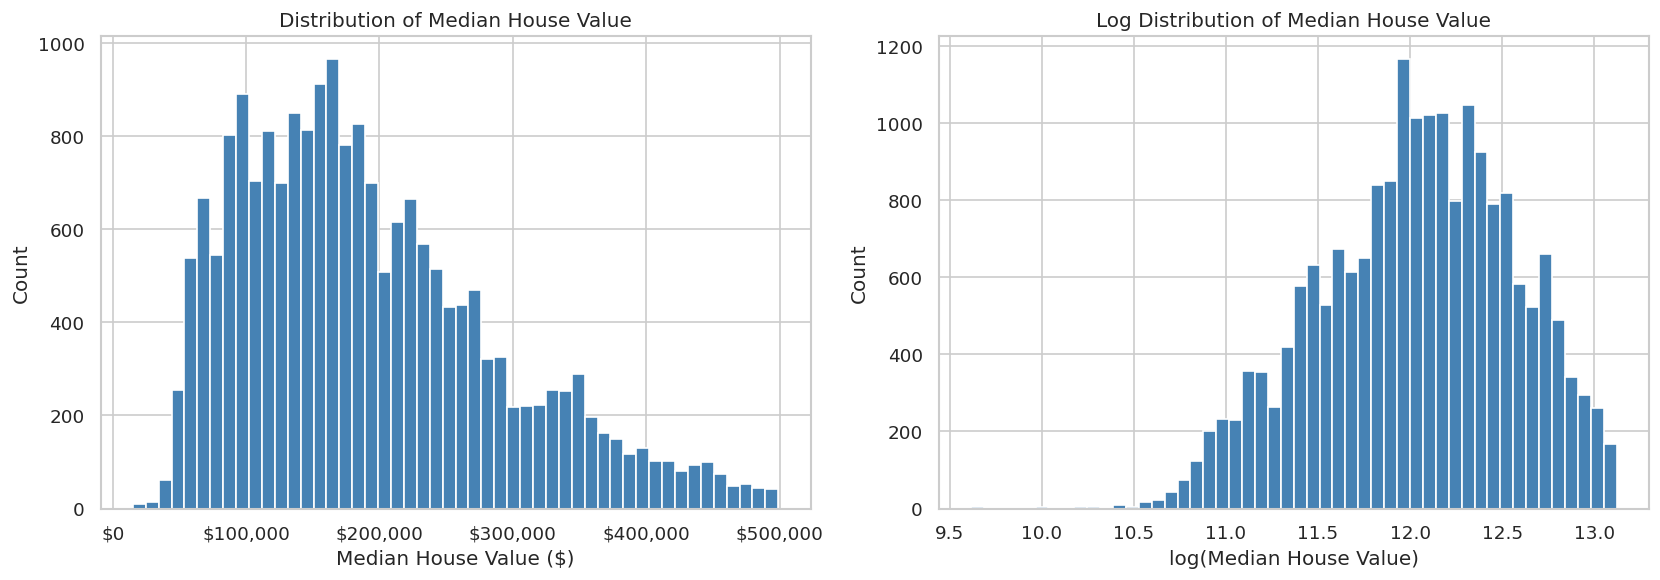

In [7]:
# ============================================================
#  EDA: TARGET DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].hist(np.log1p(df['median_house_value']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log Distribution of Median House Value')
axes[1].set_xlabel('log(Median House Value)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

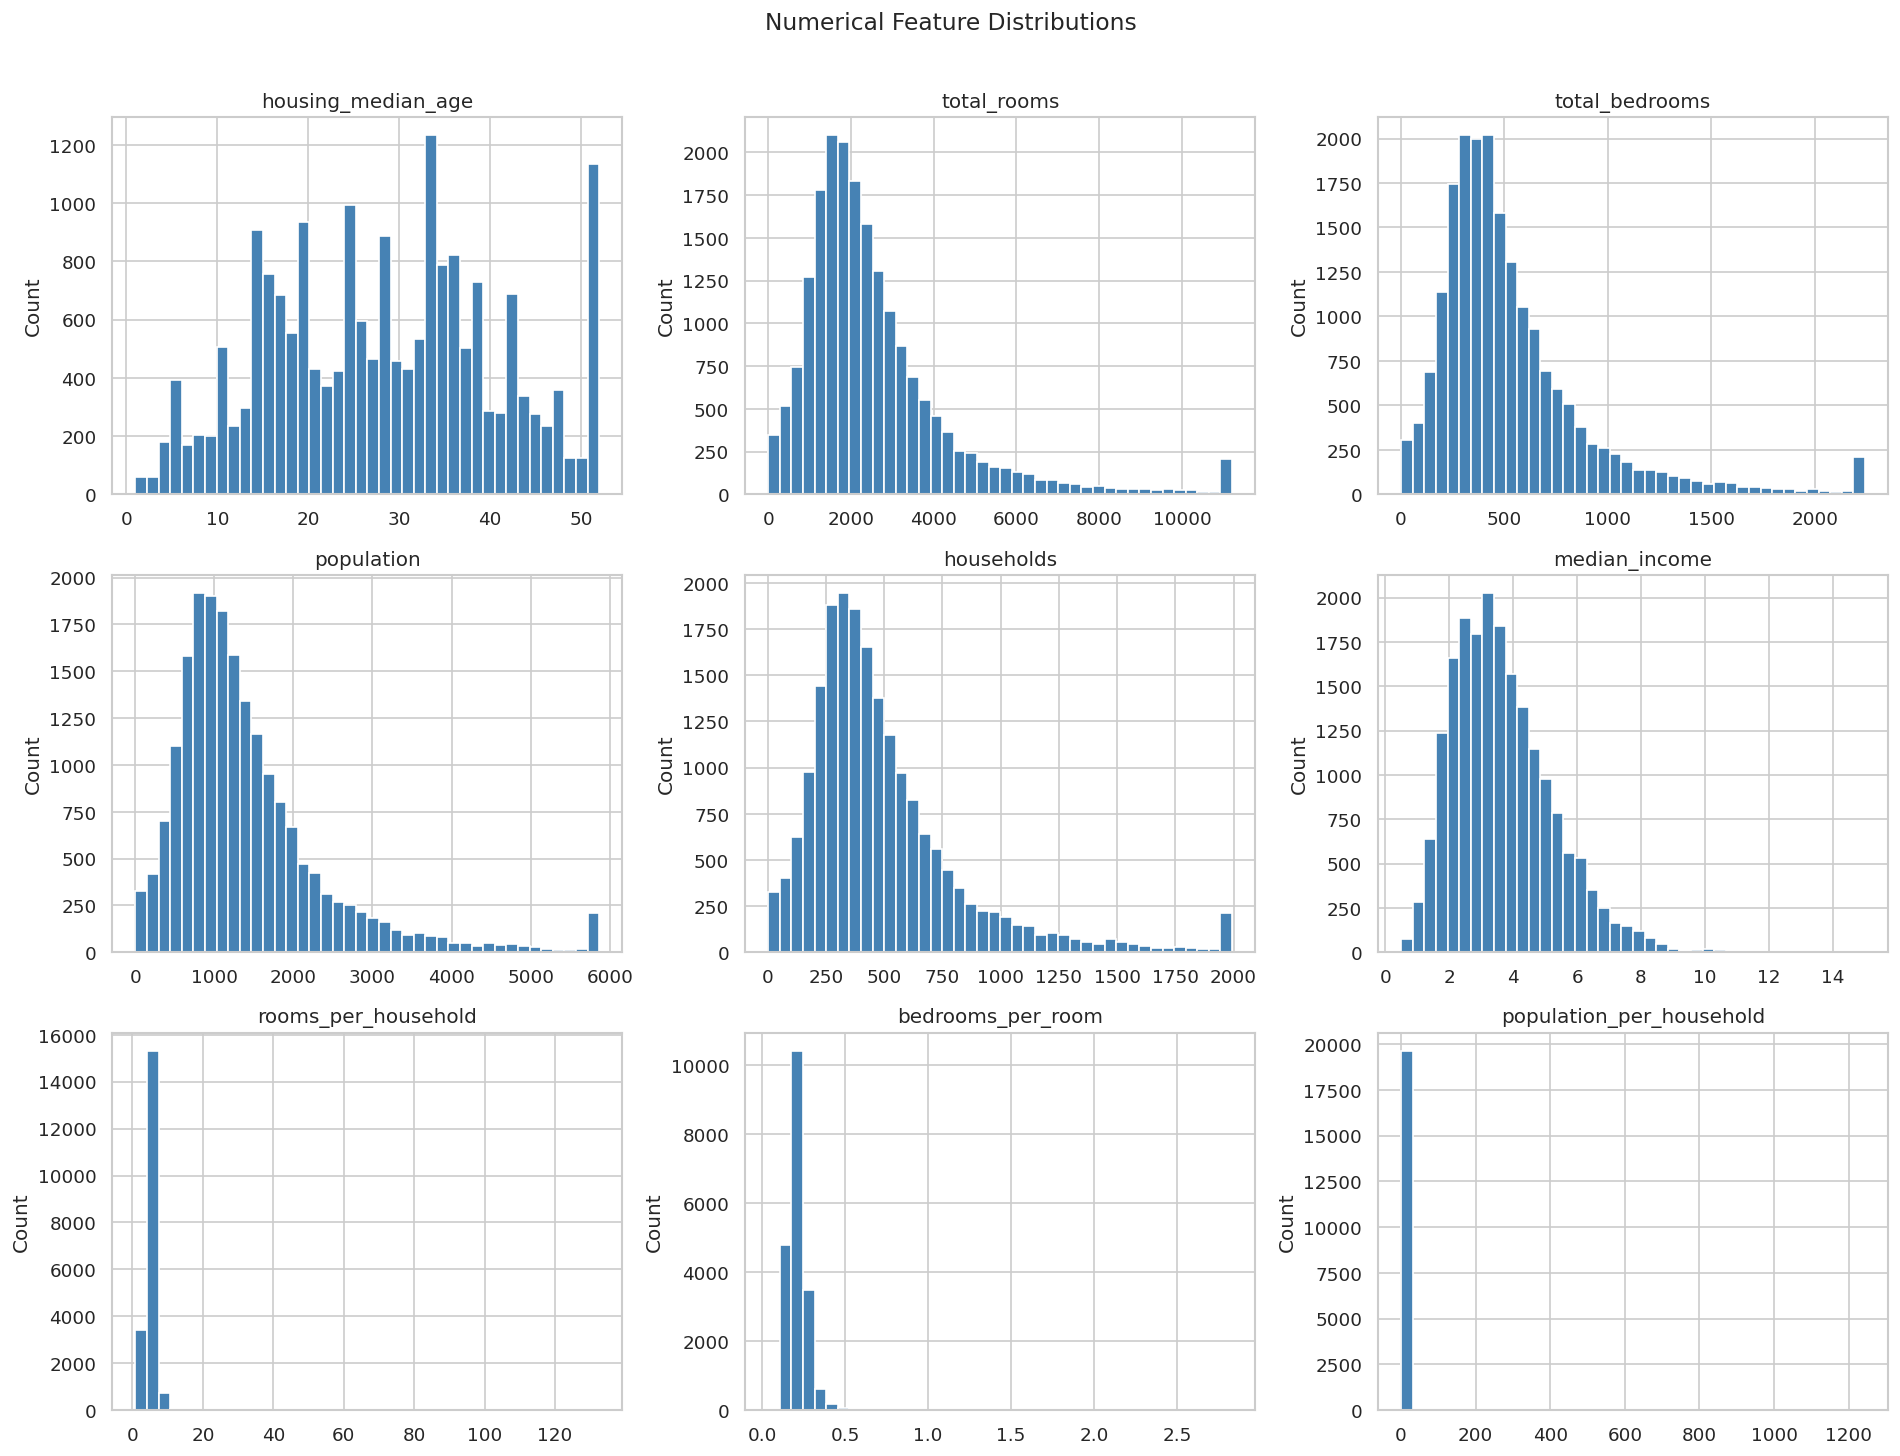

In [8]:
# ============================================================
# EDA: FEATURE DISTRIBUTIONS
# ============================================================

num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income',
            'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

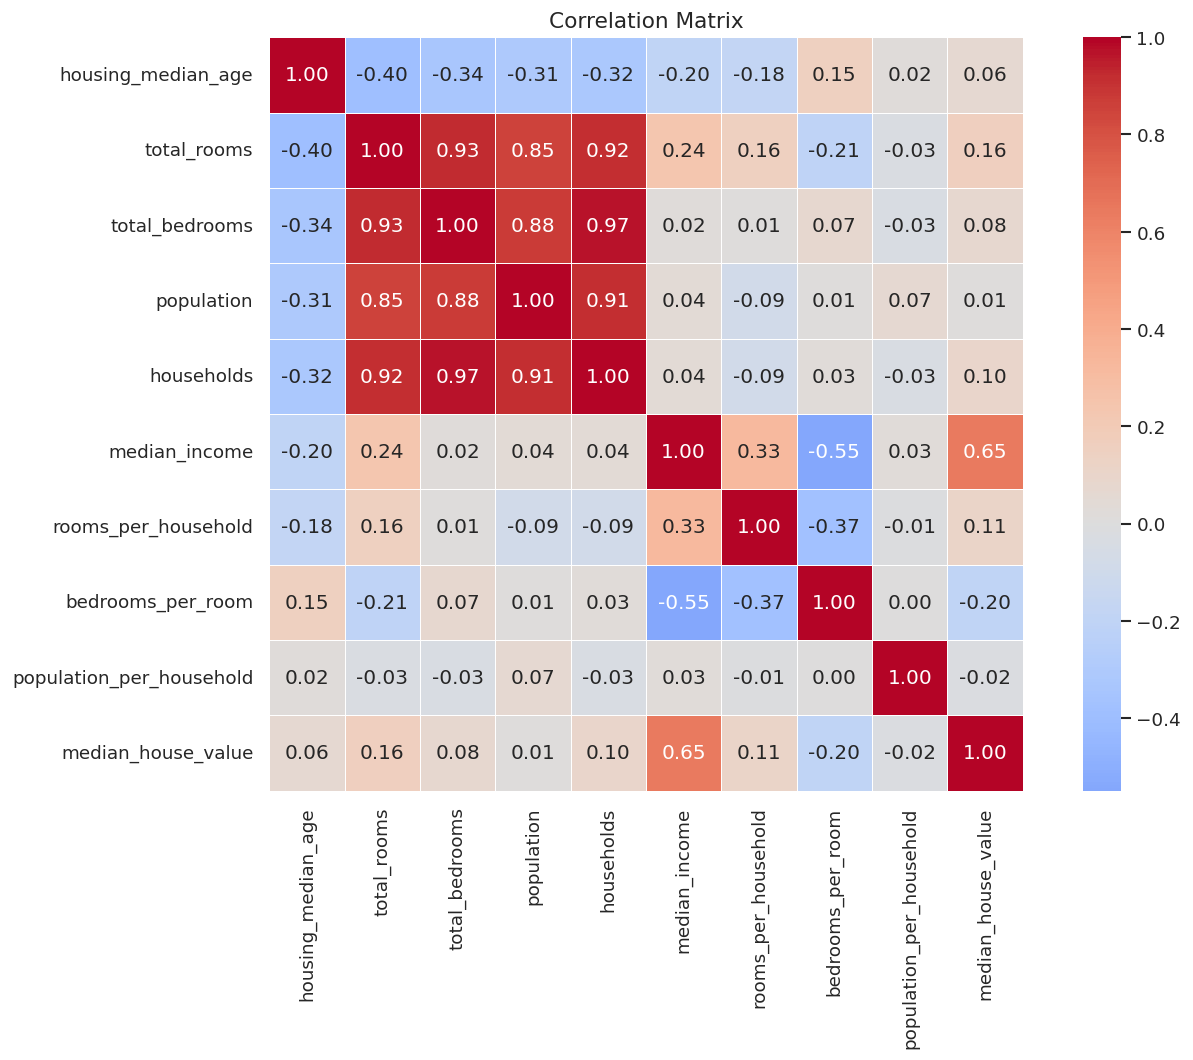

In [9]:
# ============================================================
# EDA: CORRELATION HEATMAP
# ============================================================

num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income',
            'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

corr_cols = num_cols + ['median_house_value']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

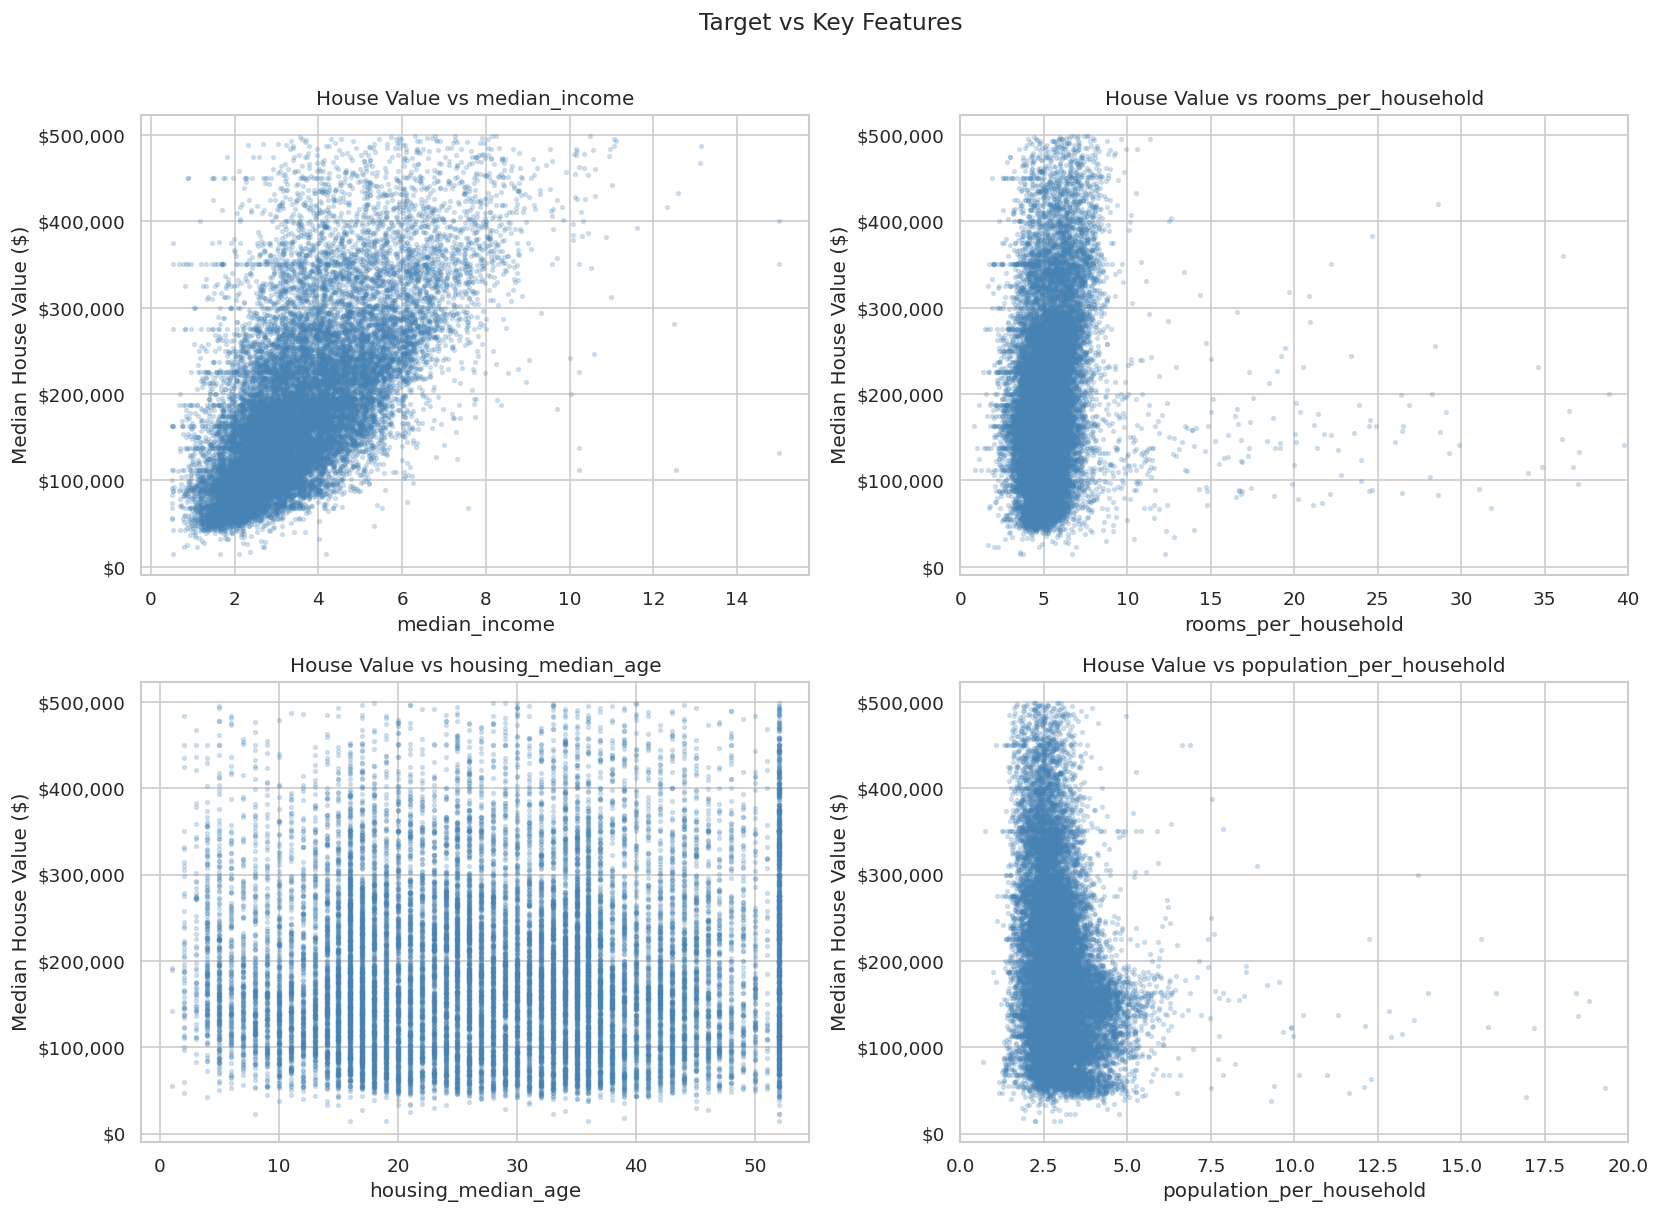

In [11]:
# ============================================================
# EDA: TARGET VS KEY FEATURES
# ============================================================

key_features = ['median_income', 'rooms_per_household',
                'housing_median_age', 'population_per_household']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].scatter(df[col], df['median_house_value'],
                    alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Median House Value ($)')
    axes[i].set_title(f'House Value vs {col}')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Set x-axis limits as requested
    if col == 'rooms_per_household':
        axes[i].set_xlim(0, 40)
    elif col == 'population_per_household':
        axes[i].set_xlim(0, 20)

plt.suptitle('Target vs Key Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('scatter_target_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

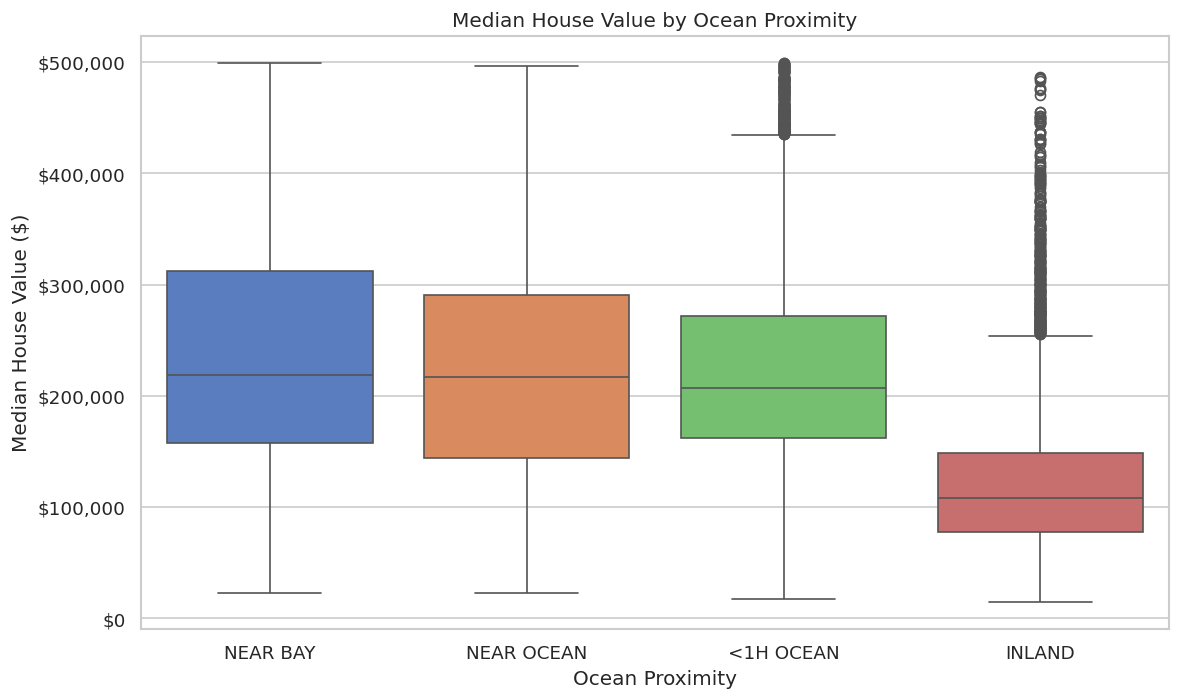

In [ ]:
# ============================================================
# EDA: BOXPLOT BY OCEAN PROXIMITY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    order=order,
    palette='muted',
    ax=ax
)
ax.set_title('Median House Value by Ocean Proximity')
ax.set_xlabel('Ocean Proximity')
ax.set_ylabel('Median House Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('boxplot_ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()

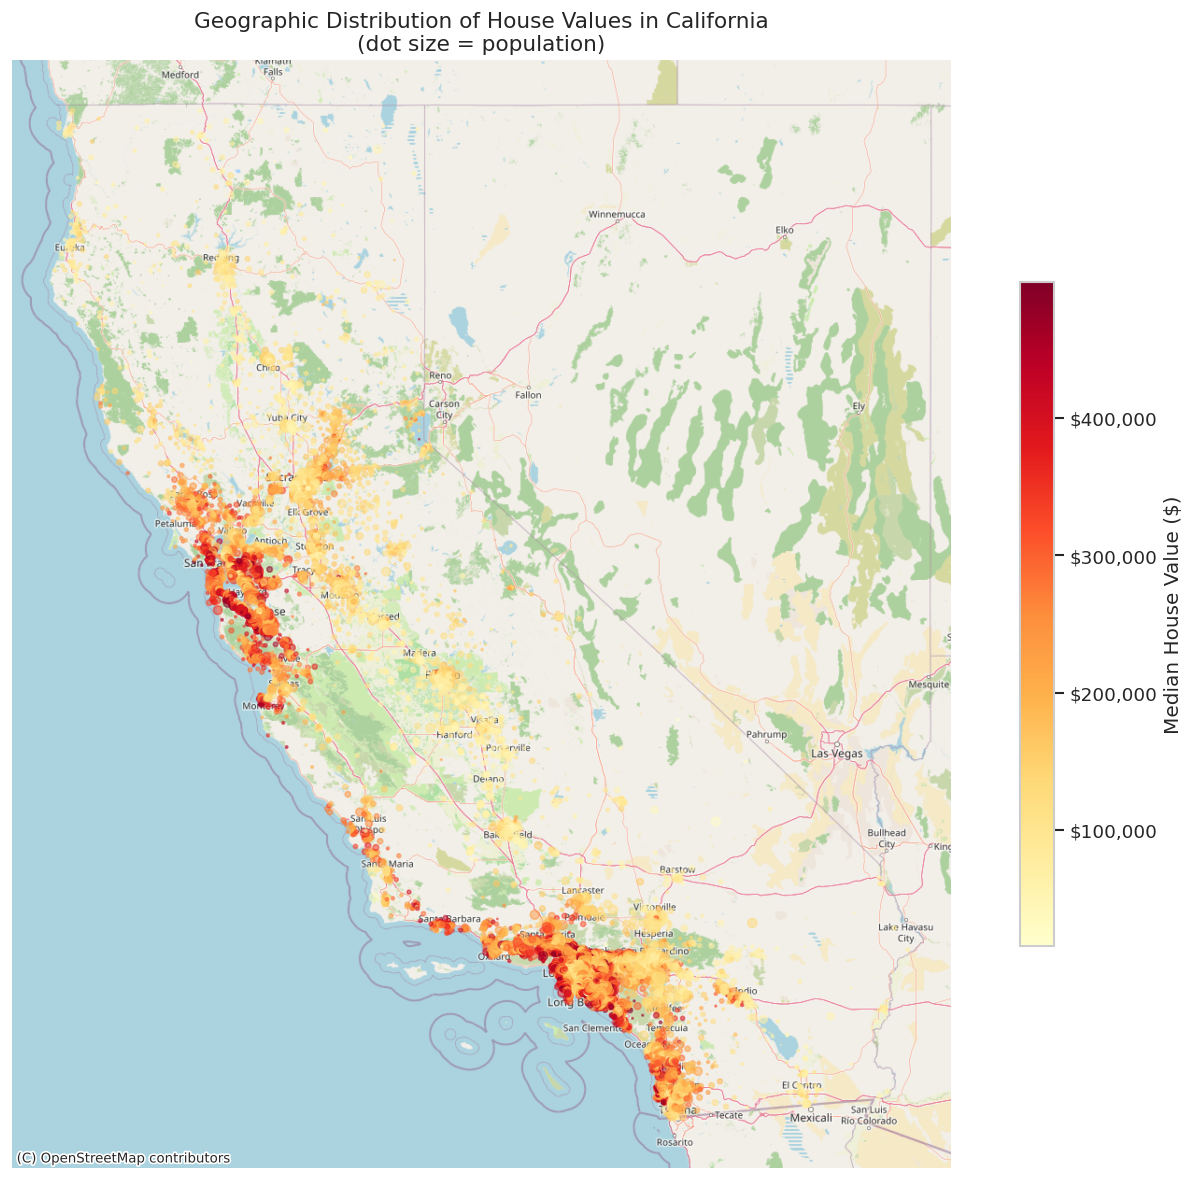

In [ ]:
# ============================================================
#  EDA: GEOGRAPHIC MAP WITH REAL BASEMAP
# ============================================================

geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column='median_house_value',
    cmap='YlOrRd',
    alpha=0.5,
    markersize=gdf['population'] / 200,
    legend=True,
    legend_kwds={
        'label': 'Median House Value ($)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'format': mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    }
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=7
)

ax.set_title('Geographic Distribution of House Values in California\n(dot size = population)',
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('geo_map_real.png', dpi=150, bbox_inches='tight')
plt.show()

##Models


In [ ]:
# ============================================================
#PREPROCESSING PIPELINE
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Define feature groups
num_features = [
    'housing_median_age', 'total_rooms', 'total_bedrooms',
    'population', 'households', 'median_income',
    'rooms_per_household', 'bedrooms_per_room', 'population_per_household'
]
cat_features = ['ocean_proximity']
target       = 'median_house_value'

X = df[num_features + cat_features]
y = df[target]

# Train / test split (80/20, fixed seed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing: scale numerics, one-hot encode categoricals
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  num_features),
    ('cat', categorical_transformer, cat_features)
])

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Features       : {len(num_features)} numerical + {len(cat_features)} categorical")

Training set   : 15,714 rows
Test set       : 3,929 rows
Features       : 9 numerical + 1 categorical


In [ ]:
# ============================================================
# METRICS HELPER
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit model, predict on test set, return dict of metrics.
    """
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    metrics = {
        'Model'     : name,
        'R2 Train'  : round(r2_score(y_tr, y_pred_train), 4),
        'R2 Test'   : round(r2_score(y_te, y_pred_test),  4),
        'RMSE Test' : round(np.sqrt(mean_squared_error(y_te, y_pred_test)), 2),
        'MAE Test'  : round(mean_absolute_error(y_te, y_pred_test), 2),
        'Train Time (s)': round(train_time, 2)
    }
    print(f"[{name}] R2={metrics['R2 Test']} | RMSE=${metrics['RMSE Test']:,.0f} | MAE=${metrics['MAE Test']:,.0f} | {train_time:.1f}s")
    return metrics

results = []

#Linear Regression


In [ ]:
# ============================================================
# MODEL 1: LINEAR REGRESSION (OLS) - BASE MODEL
# ============================================================

from sklearn.linear_model import LinearRegression

pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

results.append(evaluate_model('Linear Regression (OLS)', pipe_lr, X_train, y_train, X_test, y_test))

[Linear Regression (OLS)] R2=0.618 | RMSE=$59,772 | MAE=$44,382 | 0.0s


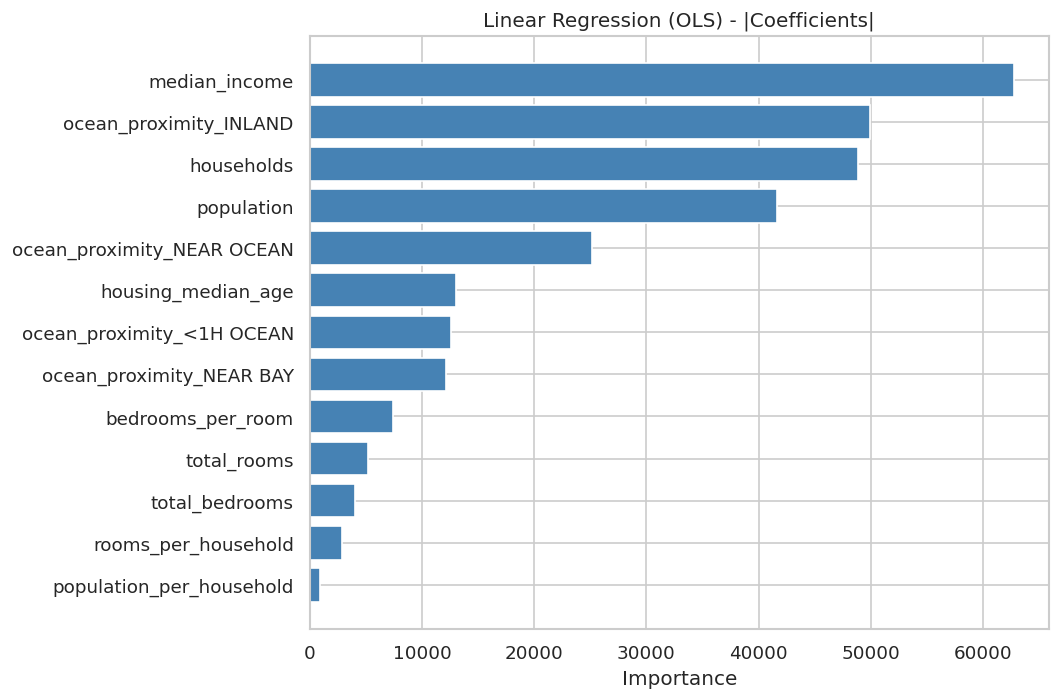

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE: LINEAR REGRESSION (OLS)
# ============================================================

def get_feature_names(pipeline):
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    return num_features + ohe.get_feature_names_out(cat_features).tolist()

def plot_importance(importances, feature_names, title, color='steelblue', top_n=15):
    feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_df = feat_df.sort_values('importance', ascending=False).head(top_n)
    feat_df = feat_df.sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(feat_df['feature'], feat_df['importance'], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    filename = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

lr_coefs = np.abs(pipe_lr.named_steps['model'].coef_)
plot_importance(lr_coefs, get_feature_names(pipe_lr),
                'Linear Regression (OLS) - |Coefficients|', color='steelblue')

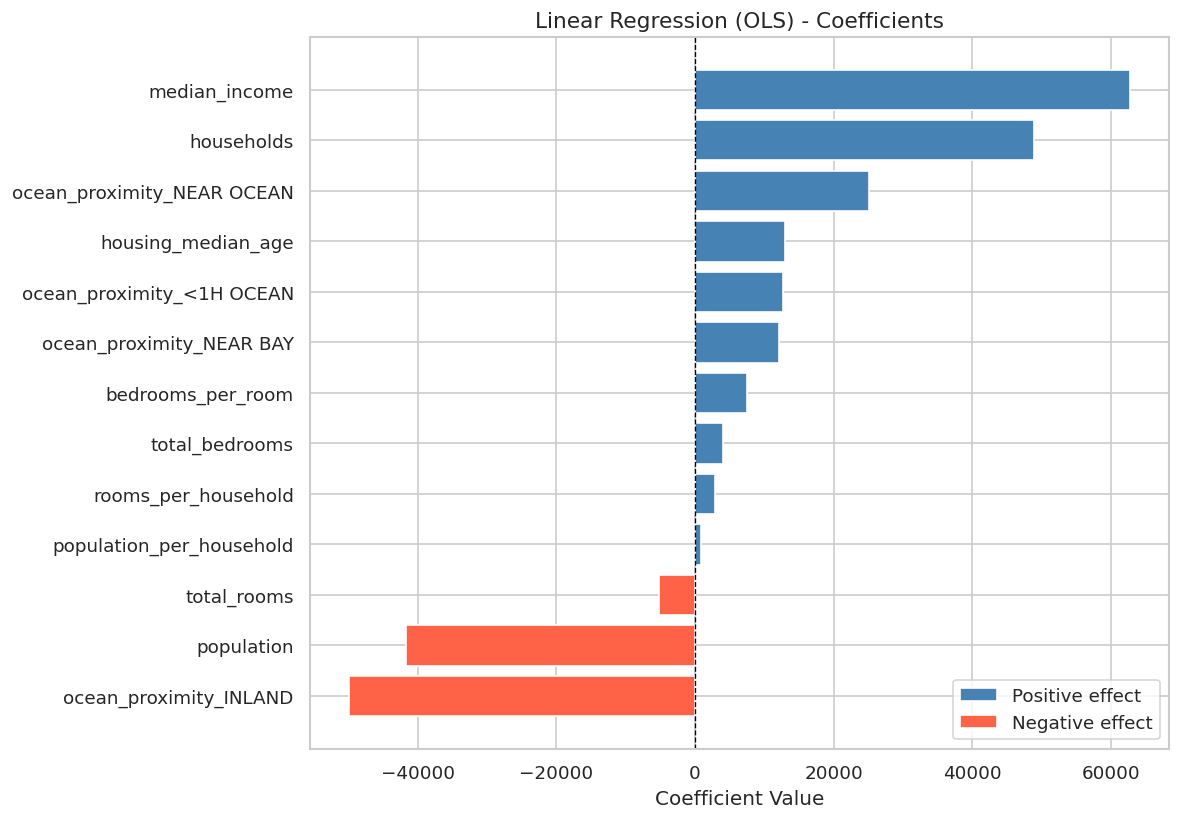

In [ ]:
# ============================================================
#COEFFICIENTS: LINEAR REGRESSION (OLS)
# ============================================================

def plot_coefficients(coefs, feature_names, title, color_pos='steelblue', color_neg='tomato', top_n=15):
    feat_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    feat_df = feat_df.reindex(feat_df['coefficient'].abs().sort_values(ascending=False).index)
    feat_df = feat_df.head(top_n).sort_values('coefficient', ascending=True)

    colors = [color_pos if c >= 0 else color_neg for c in feat_df['coefficient']]

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(feat_df['feature'], feat_df['coefficient'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Coefficient Value')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_pos, label='Positive effect'),
        Patch(facecolor=color_neg, label='Negative effect')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    filename = title.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('|', '') + '.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Extract coefficients
lr_coefs      = pipe_lr.named_steps['model'].coef_
lr_features   = get_feature_names(pipe_lr)

plot_coefficients(lr_coefs, lr_features,
                  'Linear Regression (OLS) - Coefficients')

#Lasso & Ridge

In [ ]:
# ============================================================
#  MODEL 2: LASSO & RIDGE
# ============================================================

from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV

# Ridge
pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
param_grid_ridge = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
gs_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
results.append(evaluate_model('Ridge', gs_ridge, X_train, y_train, X_test, y_test))
print(f"  Best alpha (Ridge): {gs_ridge.best_params_}")

# Lasso
pipe_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])
param_grid_lasso = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
gs_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=5, scoring='r2', n_jobs=-1)
results.append(evaluate_model('Lasso', gs_lasso, X_train, y_train, X_test, y_test))
print(f"  Best alpha (Lasso): {gs_lasso.best_params_}")

[Ridge] R2=0.618 | RMSE=$59,772 | MAE=$44,387 | 3.4s
  Best alpha (Ridge): {'model__alpha': 10.0}
[Lasso] R2=0.6179 | RMSE=$59,784 | MAE=$44,415 | 9.2s
  Best alpha (Lasso): {'model__alpha': 100.0}


Best alpha: 10.0


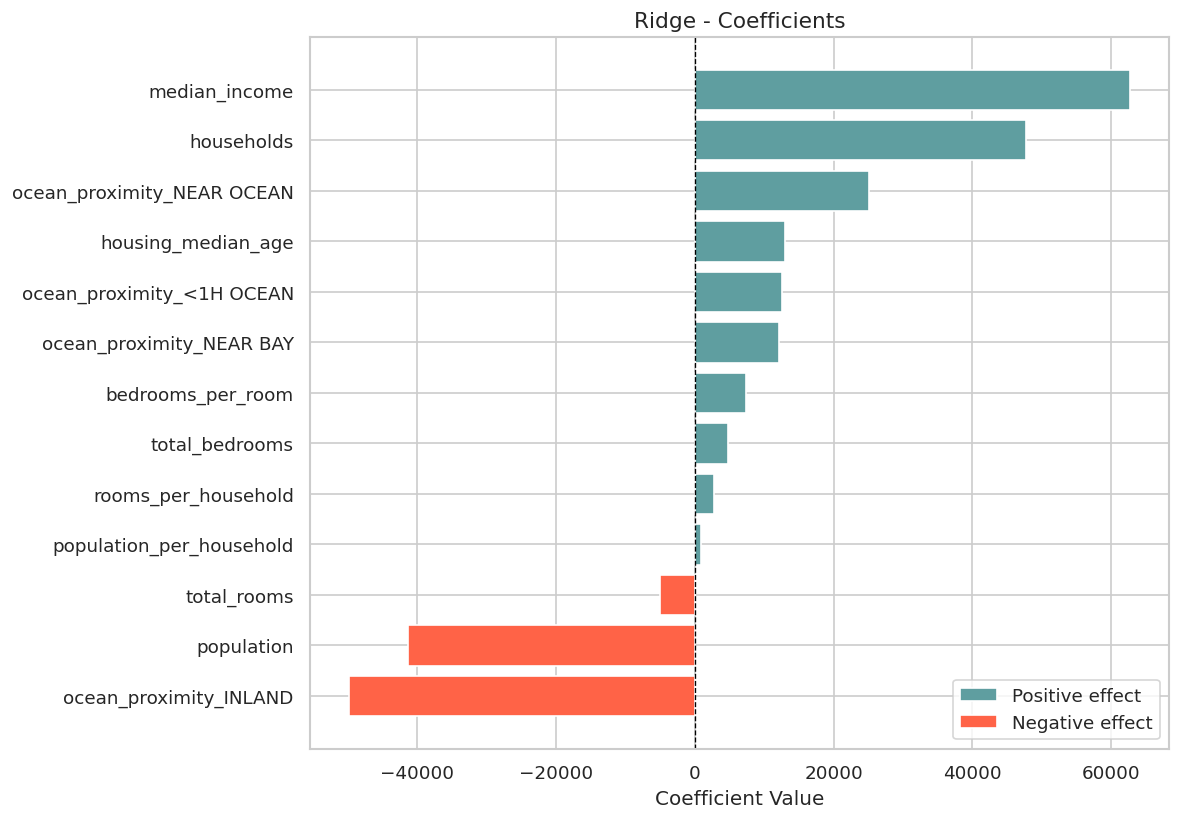

In [ ]:
# ============================================================
# COEFFICIENTS: RIDGE
# ============================================================

best_ridge    = gs_ridge.best_estimator_
ridge_coefs   = best_ridge.named_steps['model'].coef_
ridge_features = get_feature_names(best_ridge)

print(f"Best alpha: {gs_ridge.best_params_['model__alpha']}")
plot_coefficients(ridge_coefs, ridge_features,
                  'Ridge - Coefficients', color_pos='cadetblue', color_neg='tomato')

Best alpha   : 100.0
Features kept: 11 / 13
Features dropped by Lasso: 2


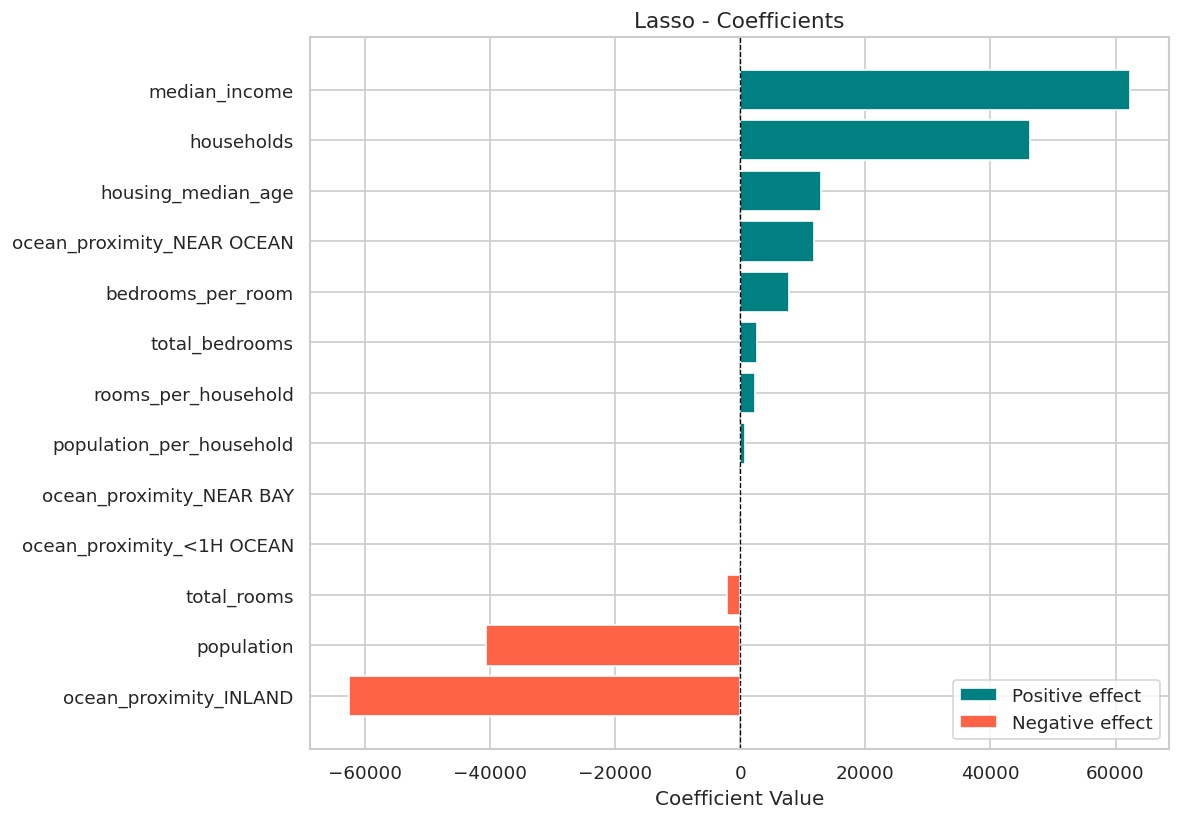

In [ ]:
# ============================================================
#COEFFICIENTS: LASSO
# ============================================================

best_lasso     = gs_lasso.best_estimator_
lasso_coefs    = best_lasso.named_steps['model'].coef_
lasso_features = get_feature_names(best_lasso)

n_dropped = (lasso_coefs == 0).sum()
print(f"Best alpha   : {gs_lasso.best_params_['model__alpha']}")
print(f"Features kept: {(lasso_coefs != 0).sum()} / {len(lasso_coefs)}")
print(f"Features dropped by Lasso: {n_dropped}")

plot_coefficients(lasso_coefs, lasso_features,
                  'Lasso - Coefficients', color_pos='teal', color_neg='tomato')

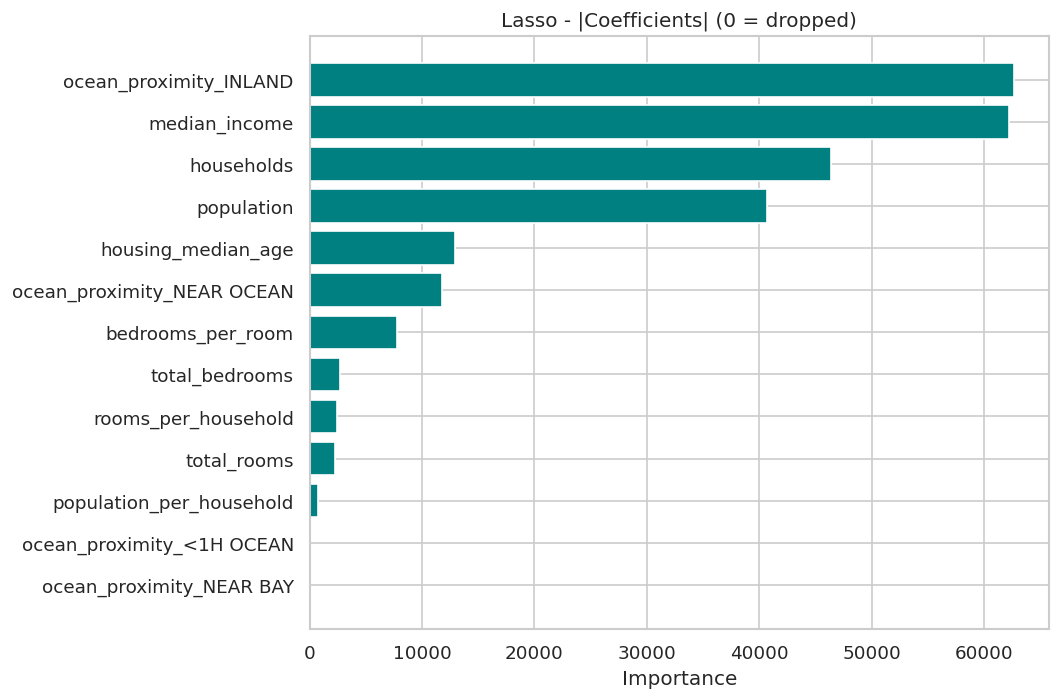

In [ ]:
# ============================================================
#VARIABLE IMPORTANCE: LASSO
# ============================================================

best_lasso = gs_lasso.best_estimator_
lasso_coefs = np.abs(best_lasso.named_steps['model'].coef_)
plot_importance(lasso_coefs, get_feature_names(best_lasso),
                'Lasso - |Coefficients| (0 = dropped)', color='teal')

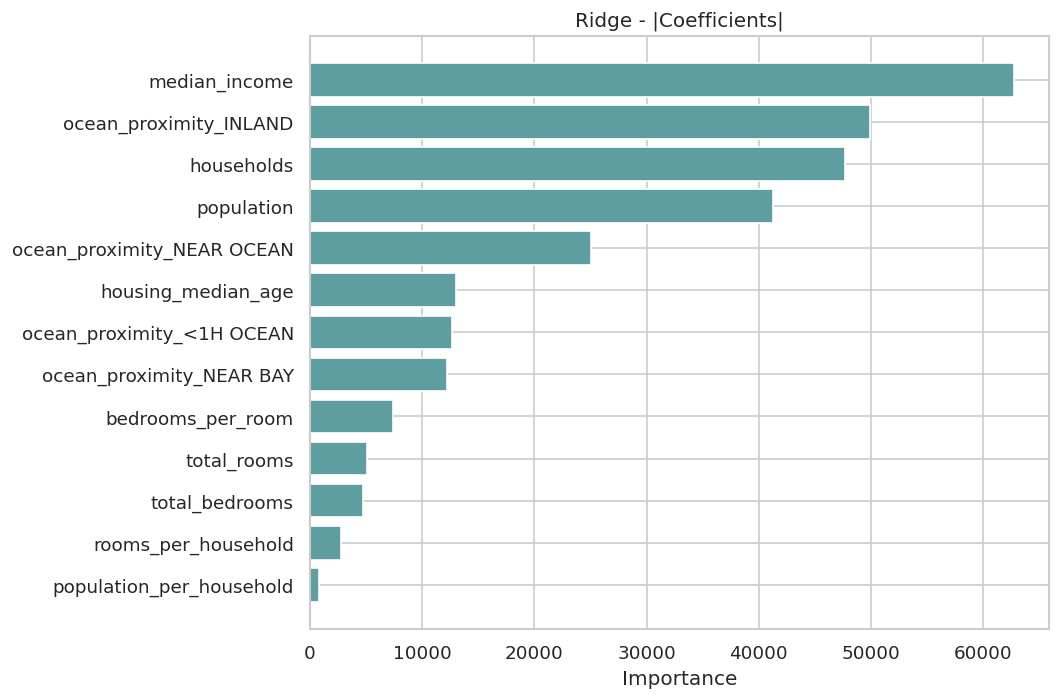

In [ ]:
# ============================================================
#  VARIABLE IMPORTANCE: RIDGE
# ============================================================

best_ridge = gs_ridge.best_estimator_
ridge_coefs = np.abs(best_ridge.named_steps['model'].coef_)
plot_importance(ridge_coefs, get_feature_names(best_ridge),
                'Ridge - |Coefficients|', color='cadetblue')

#Random Forest

In [ ]:
# ============================================================
# MODEL 3: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    'model__n_estimators'     : [300],
    'model__max_depth'        : [20],
    'model__min_samples_split': [5],
    'model__max_features'     : [0.5]
}

rs_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=1, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('Random Forest', rs_rf, X_train, y_train, X_test, y_test))
print(f"  Best params (RF): {rs_rf.best_params_}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[Random Forest] R2=0.7063 | RMSE=$52,411 | MAE=$37,760 | 70.9s
  Best params (RF): {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__max_features': 0.5, 'model__max_depth': 20}


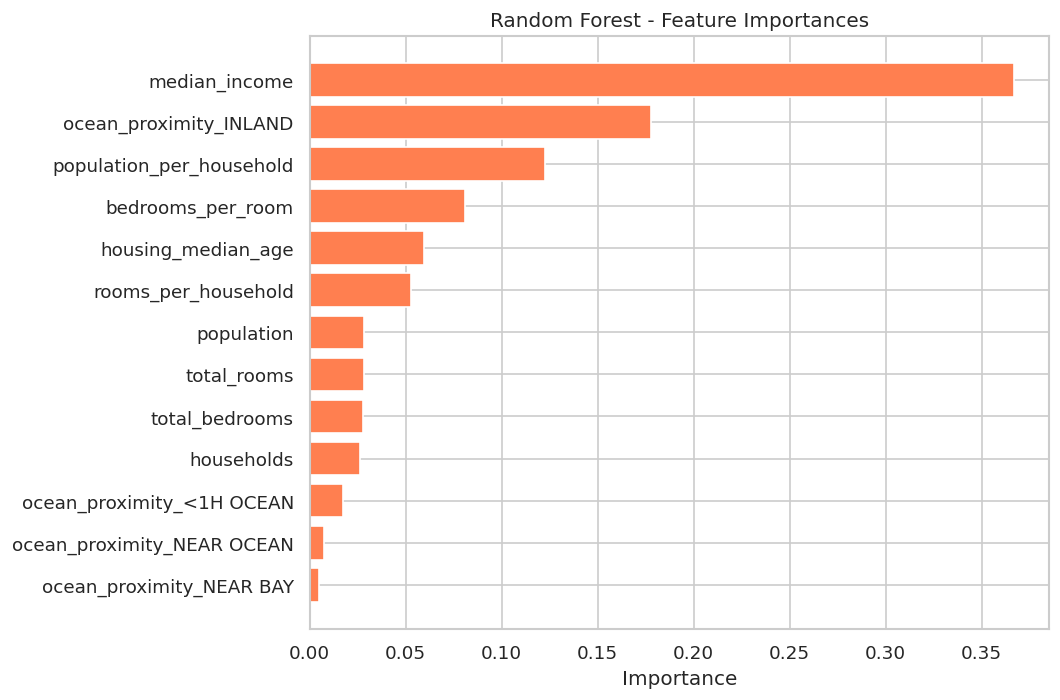

In [ ]:
# ============================================================
#VARIABLE IMPORTANCE: RANDOM FOREST
# ============================================================

best_rf = rs_rf.best_estimator_
rf_importances = best_rf.named_steps['model'].feature_importances_
plot_importance(rf_importances, get_feature_names(best_rf),
                'Random Forest - Feature Importances', color='coral')

#Gradient Boosting

In [ ]:
# ============================================================
# MODEL 4: GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_dist_gb = {
    'model__n_estimators'  : [200],
    'model__learning_rate' : [0.05],
    'model__max_depth'     : [5],
    'model__subsample'     : [0.8]
}

rs_gb = RandomizedSearchCV(
    pipe_gb, param_dist_gb,
    n_iter=1, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('Gradient Boosting', rs_gb, X_train, y_train, X_test, y_test))
print(f"  Best params (GB): {rs_gb.best_params_}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[Gradient Boosting] R2=0.7071 | RMSE=$52,345 | MAE=$37,584 | 47.7s
  Best params (GB): {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05}


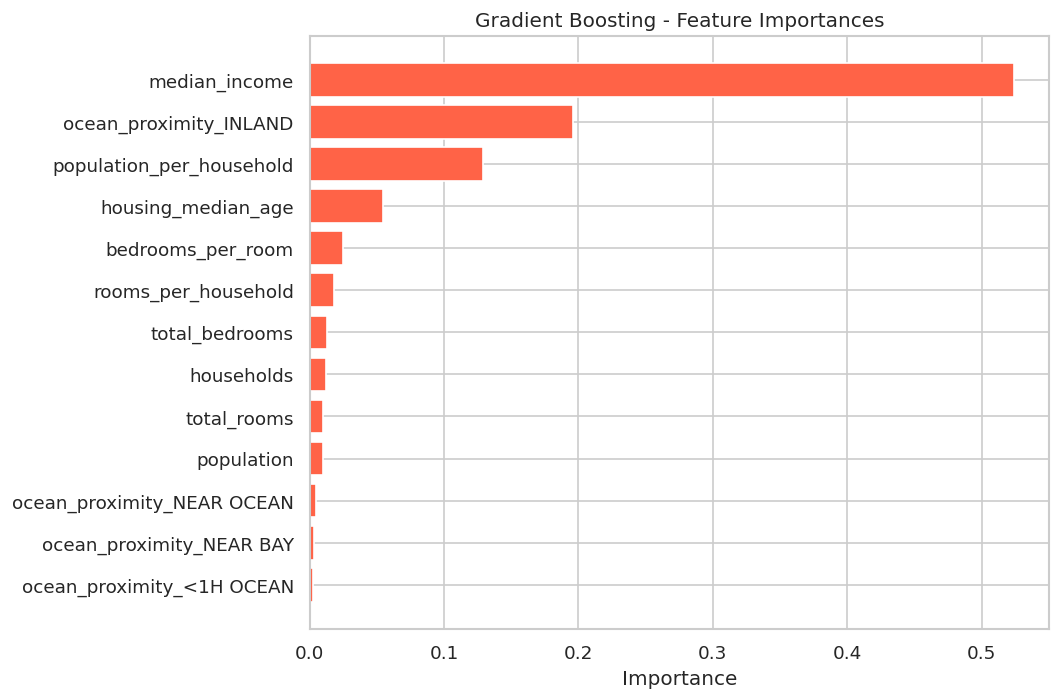

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE: GRADIENT BOOSTING
# ============================================================

best_gb = rs_gb.best_estimator_
gb_importances = best_gb.named_steps['model'].feature_importances_
plot_importance(gb_importances, get_feature_names(best_gb),
                'Gradient Boosting - Feature Importances', color='tomato')

#SVM

In [ ]:
# ============================================================
#  MODEL 5: SUPPORT VECTOR MACHINE (SVR)
# ============================================================

from sklearn.svm import SVR

pipe_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVR())
])

param_dist_svr = {
    'model__C'      : [100.0],
    'model__epsilon': [0.5],
    'model__kernel' : ['linear']
}

rs_svr = RandomizedSearchCV(
    pipe_svr, param_dist_svr,
    n_iter=1, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('SVM', rs_svr, X_train, y_train, X_test, y_test))
print(f"  Best params (SVM): {rs_svr.best_params_}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[SVM] R2=0.5994 | RMSE=$61,209 | MAE=$43,639 | 34.9s
  Best params (SVM): {'model__kernel': 'linear', 'model__epsilon': 0.5, 'model__C': 100.0}


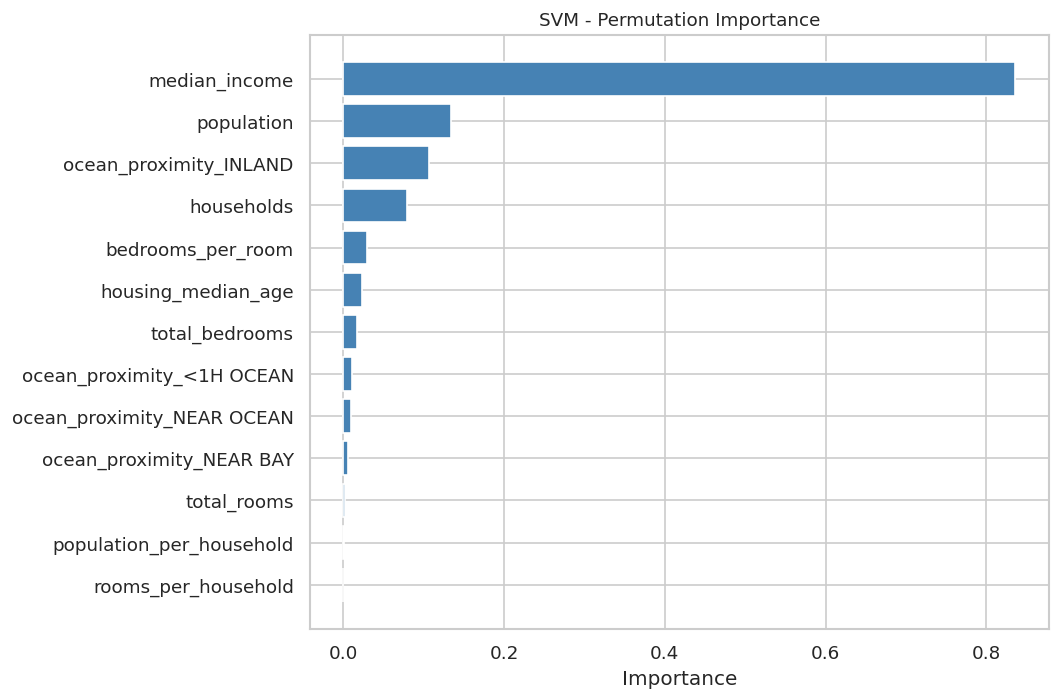

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE: SVM - PERMUTATION
# ============================================================

from sklearn.inspection import permutation_importance

X_test_proc = rs_svr.best_estimator_.named_steps['preprocessor'].transform(X_test)
svm_model   = rs_svr.best_estimator_.named_steps['model']

perm_svm = permutation_importance(
    svm_model, X_test_proc, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

feat_df_svm = pd.DataFrame({
    'feature':    get_feature_names(rs_svr.best_estimator_),
    'importance': perm_svm.importances_mean
})
feat_df_svm = feat_df_svm.sort_values('importance', ascending=False).head(15)
feat_df_svm = feat_df_svm.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(feat_df_svm['feature'], feat_df_svm['importance'], color='steelblue')
ax.set_title('SVM - Permutation Importance', fontsize=11)
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('variable_importance_svm.png', dpi=150, bbox_inches='tight')
plt.show()

#Neural Network

In [ ]:
# ============================================================
# MODEL 6: NEURAL NETWORK (MLP)
# ============================================================

from sklearn.neural_network import MLPRegressor

pipe_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(max_iter=500, random_state=42))
])

param_dist_mlp = {
    'model__hidden_layer_sizes': [(64, 32)],
    'model__activation'        : ['relu'],
    'model__alpha'             : [0.0001],
    'model__learning_rate_init': [0.01]
}

rs_mlp = RandomizedSearchCV(
    pipe_mlp, param_dist_mlp,
    n_iter=1, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)

results.append(evaluate_model('Neural Network (MLP)', rs_mlp, X_train, y_train, X_test, y_test))
print(f"  Best params (MLP): {rs_mlp.best_params_}")

[Neural Network (MLP)] R2=0.6796 | RMSE=$54,747 | MAE=$39,432 | 58.4s
  Best params (MLP): {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (64, 32), 'model__alpha': 0.0001, 'model__activation': 'relu'}


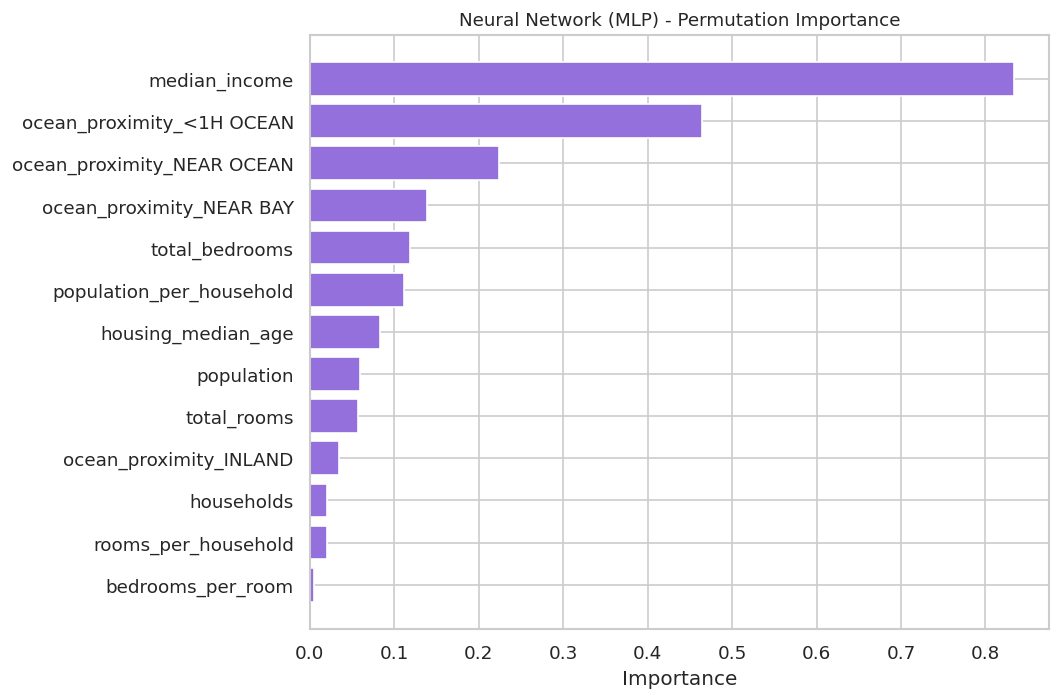

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE: NEURAL NETWORK (MLP) - PERMUTATION
# ============================================================

from sklearn.inspection import permutation_importance

X_test_proc = rs_mlp.best_estimator_.named_steps['preprocessor'].transform(X_test)
mlp_model   = rs_mlp.best_estimator_.named_steps['model']

perm = permutation_importance(
    mlp_model, X_test_proc, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 6))

feat_df = pd.DataFrame({
    'feature':    get_feature_names(rs_mlp.best_estimator_),
    'importance': perm.importances_mean
})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)
feat_df = feat_df.sort_values('importance', ascending=True)

ax.barh(feat_df['feature'], feat_df['importance'], color='mediumpurple')
ax.set_title('Neural Network (MLP) - Permutation Importance', fontsize=11)
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('variable_importance_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

#Comparaison

                  Model  R2 Train  R2 Test  RMSE Test   MAE Test  Train Time (s)
      Gradient Boosting    0.7714   0.7071 52345.1800 37584.1200         47.7300
          Random Forest    0.9341   0.7063 52410.7900 37759.8200         70.9400
   Neural Network (MLP)    0.6803   0.6796 54747.3200 39431.6300         58.3800
Linear Regression (OLS)    0.6111   0.6180 59771.8000 44381.5800          0.0300
                  Ridge    0.6111   0.6180 59771.8500 44387.3300          3.4300
                  Lasso    0.6110   0.6179 59783.9000 44415.4300          9.1600
                    SVM    0.5853   0.5994 61209.1700 43638.7100         34.9400


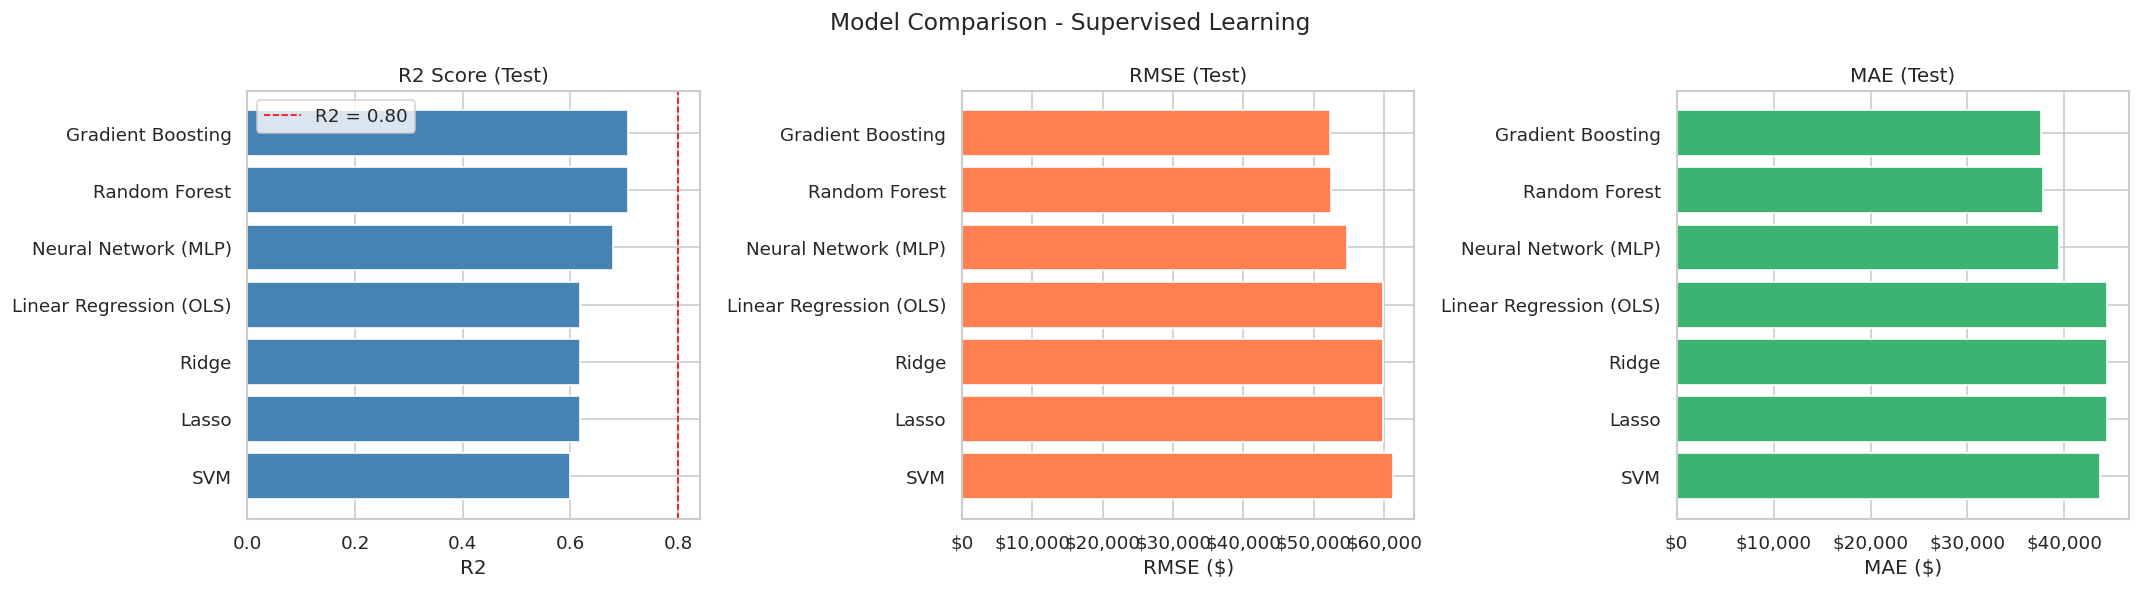

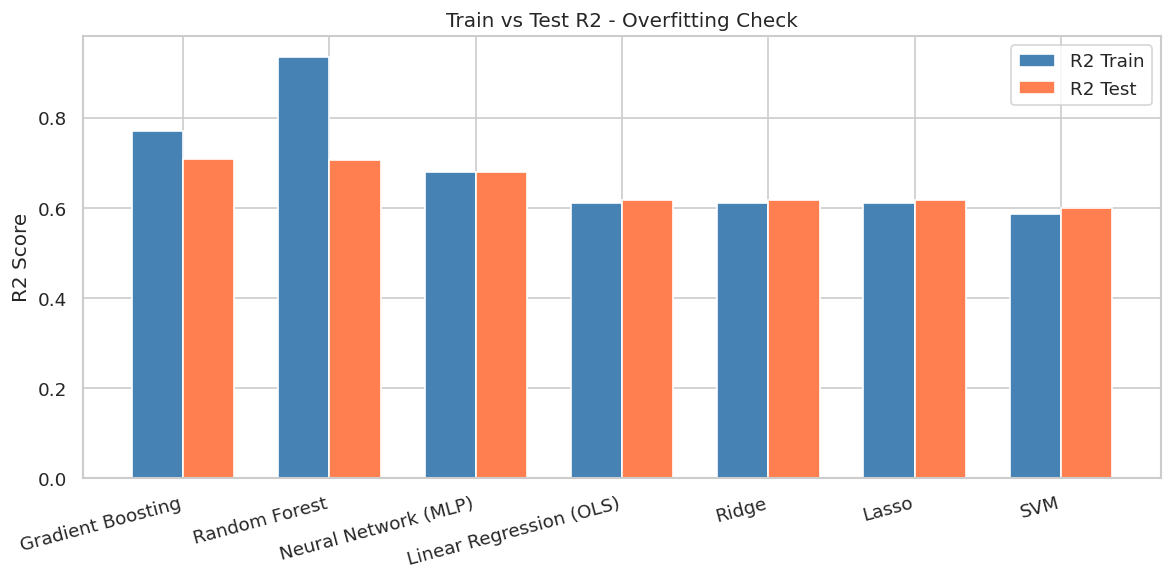

In [ ]:
# ============================================================
# RESULTS COMPARISON
# ============================================================

# --- Summary table ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Test', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# --- Bar chart: R2 Test scores ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['steelblue'] * len(results_df)

# R2 Test
axes[0].barh(results_df['Model'], results_df['R2 Test'], color='steelblue')
axes[0].set_title('R2 Score (Test)')
axes[0].set_xlabel('R2')
axes[0].axvline(x=0.8, color='red', linestyle='--', linewidth=1, label='R2 = 0.80')
axes[0].legend()
axes[0].invert_yaxis()

# RMSE Test
axes[1].barh(results_df['Model'], results_df['RMSE Test'], color='coral')
axes[1].set_title('RMSE (Test)')
axes[1].set_xlabel('RMSE ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

# MAE Test
axes[2].barh(results_df['Model'], results_df['MAE Test'], color='mediumseagreen')
axes[2].set_title('MAE (Test)')
axes[2].set_xlabel('MAE ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].invert_yaxis()

plt.suptitle('Model Comparison - Supervised Learning', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Overfitting check: Train vs Test R2 ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['R2 Train'], width, label='R2 Train', color='steelblue')
ax.bar(x + width/2, results_df['R2 Test'],  width, label='R2 Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('R2 Score')
ax.set_title('Train vs Test R2 - Overfitting Check')
ax.legend()
plt.tight_layout()
plt.savefig('overfitting_check.png', dpi=150, bbox_inches='tight')
plt.show()

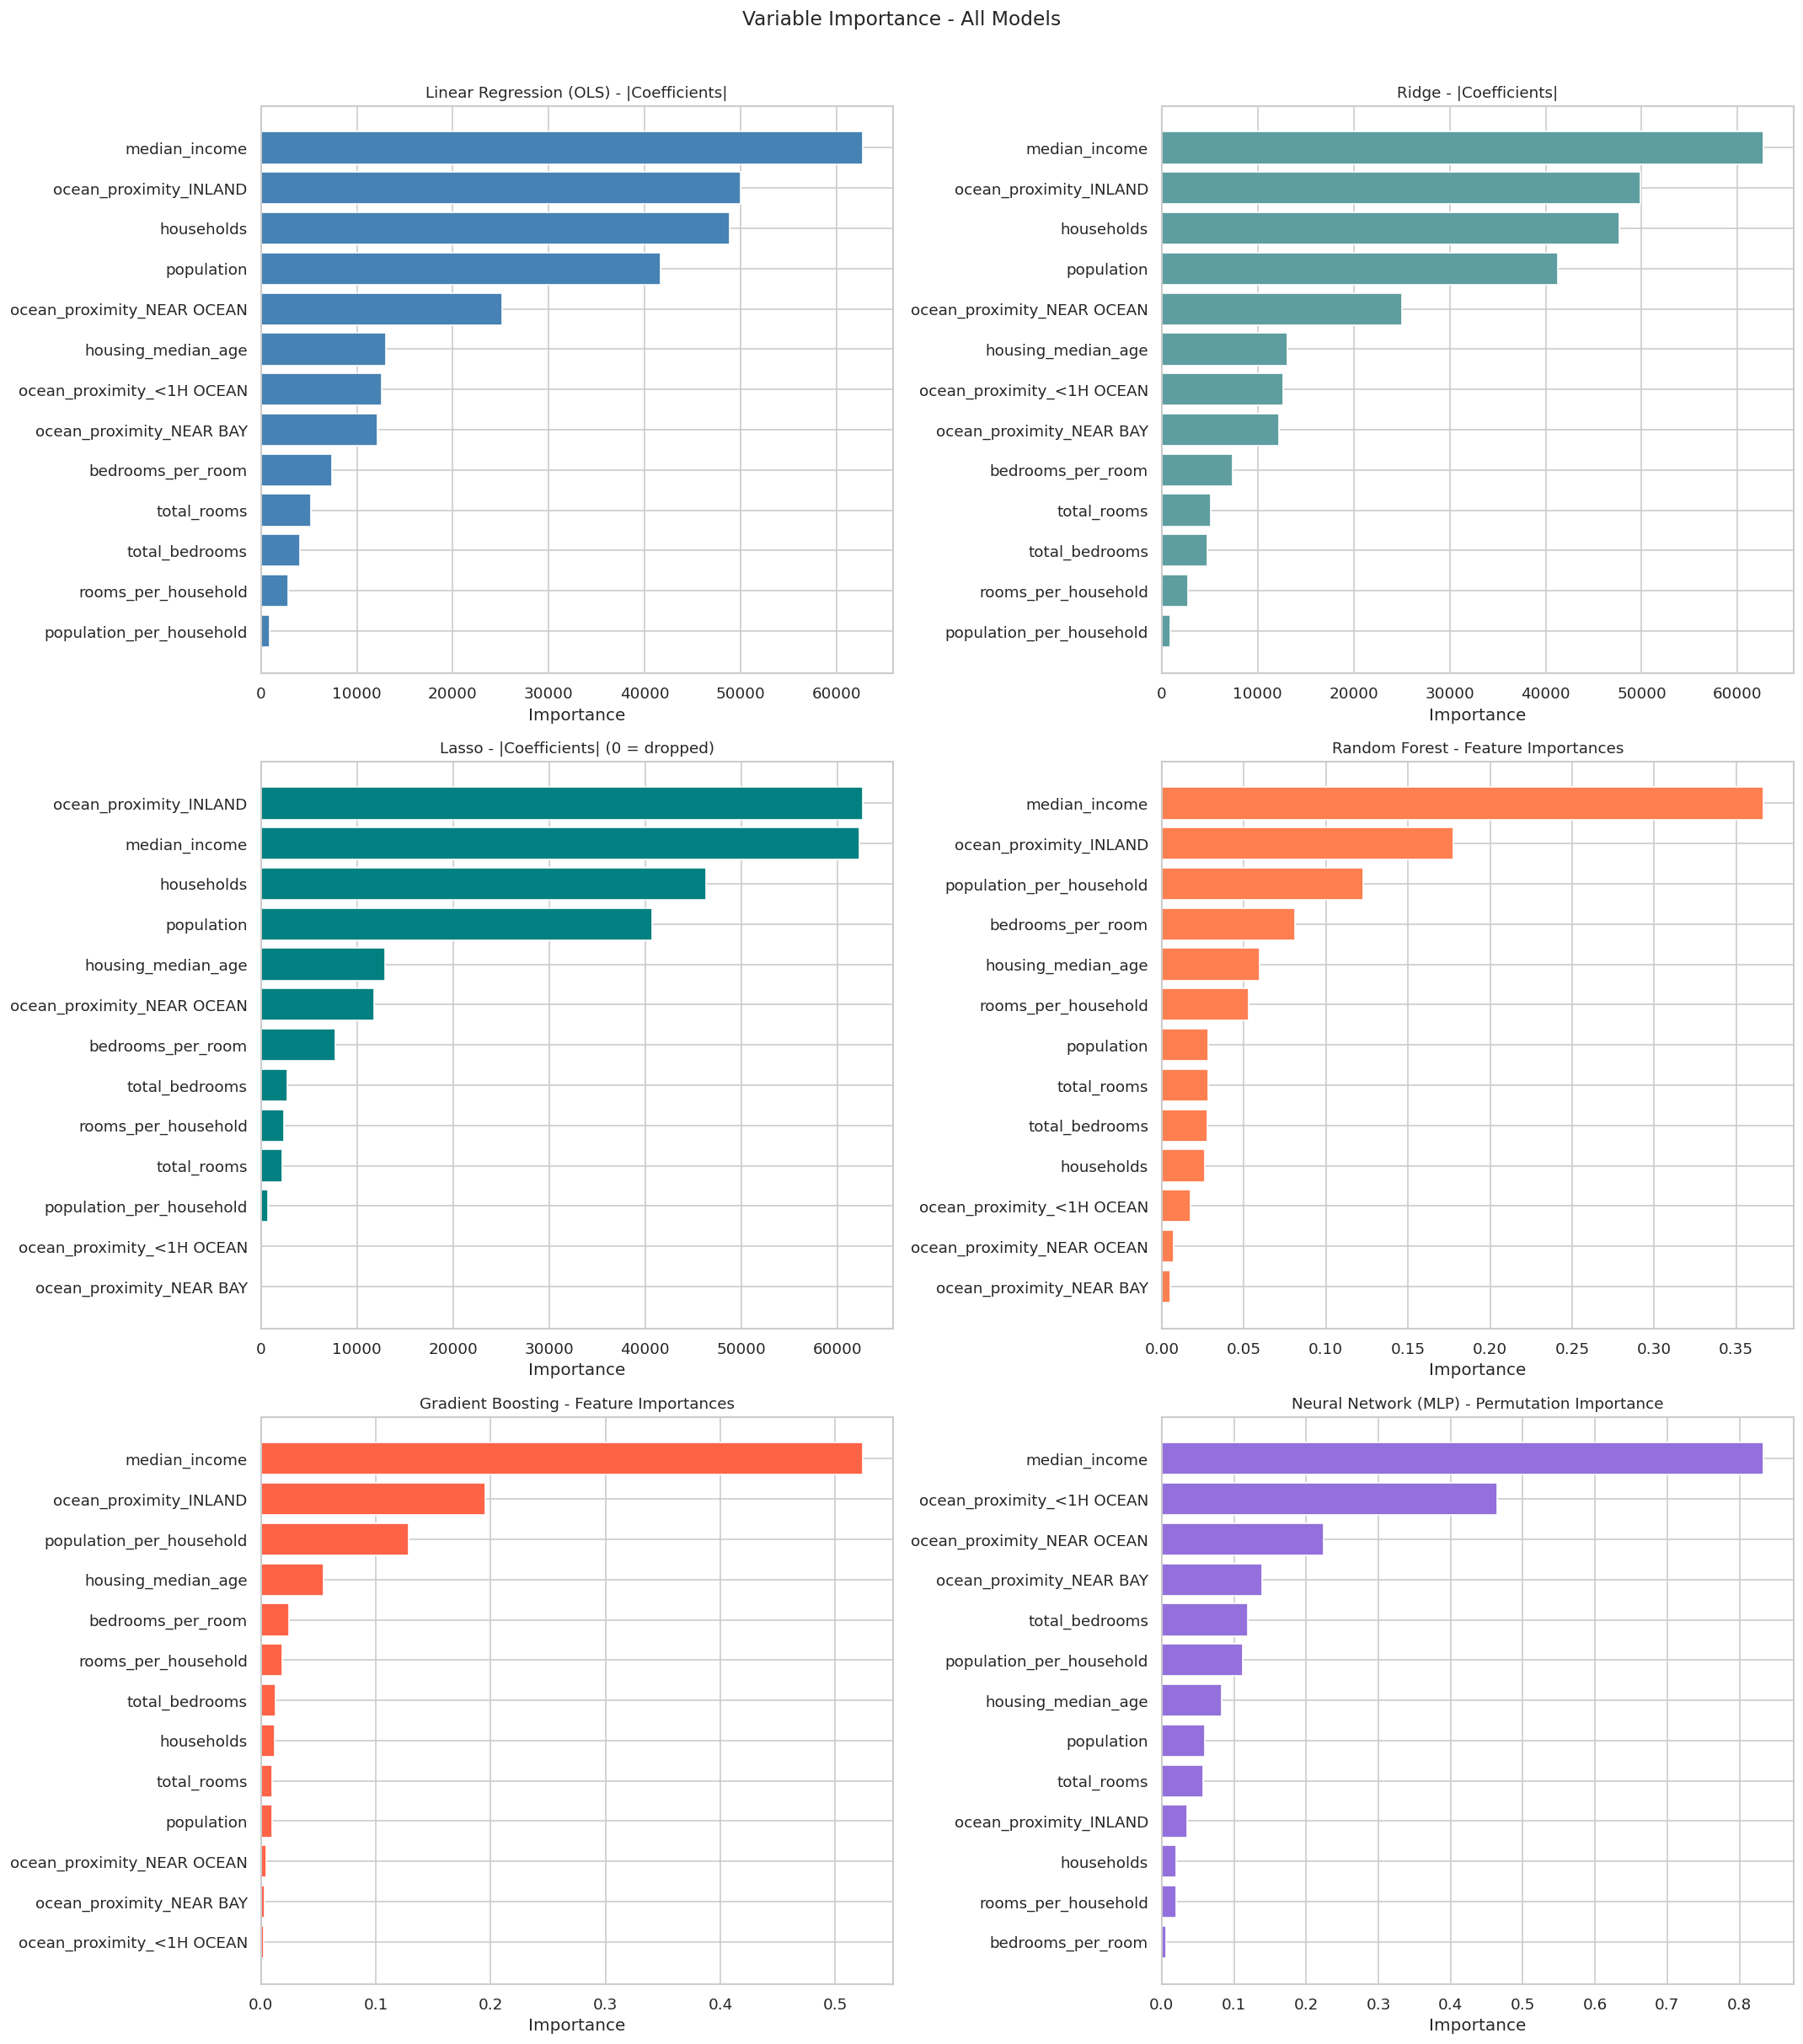

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE FOR ALL MODELS COMPARISON
# ============================================================

# --- Get feature names after preprocessing ---
ohe_features = (pipe_lr.named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(cat_features).tolist())
all_features = num_features + ohe_features

def get_feature_names(pipeline):
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    return num_features + ohe.get_feature_names_out(cat_features).tolist()

# ---- helper: plot top N features ----
def plot_importance(importances, feature_names, title, ax, color='steelblue', top_n=15):
    feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_df = feat_df.sort_values('importance', ascending=False).head(top_n)
    feat_df = feat_df.sort_values('importance', ascending=True)
    ax.barh(feat_df['feature'], feat_df['importance'], color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance')

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

# --- 1. Linear Regression (OLS) - absolute coefficients ---
lr_coefs = np.abs(pipe_lr.named_steps['model'].coef_)
plot_importance(lr_coefs, get_feature_names(pipe_lr),
                'Linear Regression (OLS) - |Coefficients|', axes[0], color='steelblue')

# --- 2. Ridge - absolute coefficients ---
best_ridge = gs_ridge.best_estimator_
ridge_coefs = np.abs(best_ridge.named_steps['model'].coef_)
plot_importance(ridge_coefs, get_feature_names(best_ridge),
                'Ridge - |Coefficients|', axes[1], color='cadetblue')

# --- 3. Lasso - absolute coefficients ---
best_lasso = gs_lasso.best_estimator_
lasso_coefs = np.abs(best_lasso.named_steps['model'].coef_)
plot_importance(lasso_coefs, get_feature_names(best_lasso),
                'Lasso - |Coefficients| (0 = dropped)', axes[2], color='teal')

# --- 4. Random Forest - built-in feature importances ---
best_rf = rs_rf.best_estimator_
rf_importances = best_rf.named_steps['model'].feature_importances_
plot_importance(rf_importances, get_feature_names(best_rf),
                'Random Forest - Feature Importances', axes[3], color='coral')

# --- 5. Gradient Boosting - built-in feature importances ---
best_gb = rs_gb.best_estimator_
gb_importances = best_gb.named_steps['model'].feature_importances_
plot_importance(gb_importances, get_feature_names(best_gb),
                'Gradient Boosting - Feature Importances', axes[4], color='tomato')

# --- 6. Neural Network - permutation importance (no built-in) ---
from sklearn.inspection import permutation_importance

# Run on a subsample for speed
X_test_proc = best_rf.named_steps['preprocessor'].transform(X_test)
mlp_model   = rs_mlp.best_estimator_.named_steps['model']

perm = permutation_importance(
    mlp_model, X_test_proc, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
plot_importance(perm.importances_mean, get_feature_names(rs_mlp.best_estimator_),
                'Neural Network (MLP) - Permutation Importance', axes[5], color='mediumpurple')

plt.suptitle('Variable Importance - All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('variable_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

##Final Model Grandiant Boosting


In [ ]:
# ============================================================
# Final Model: GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_dist_gb = {
    'model__n_estimators'  : [200],
    'model__learning_rate' : [0.025],
    'model__max_depth'     : [7],
    'model__subsample'     : [0.8]
}

rs_gb = RandomizedSearchCV(
    pipe_gb, param_dist_gb,
    n_iter=1, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('Gradient Boosting', rs_gb, X_train, y_train, X_test, y_test))
print(f"  Best params (GB): {rs_gb.best_params_}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[Gradient Boosting] R2=0.7078 | RMSE=$52,280 | MAE=$37,345 | 105.9s
  Best params (GB): {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.025}


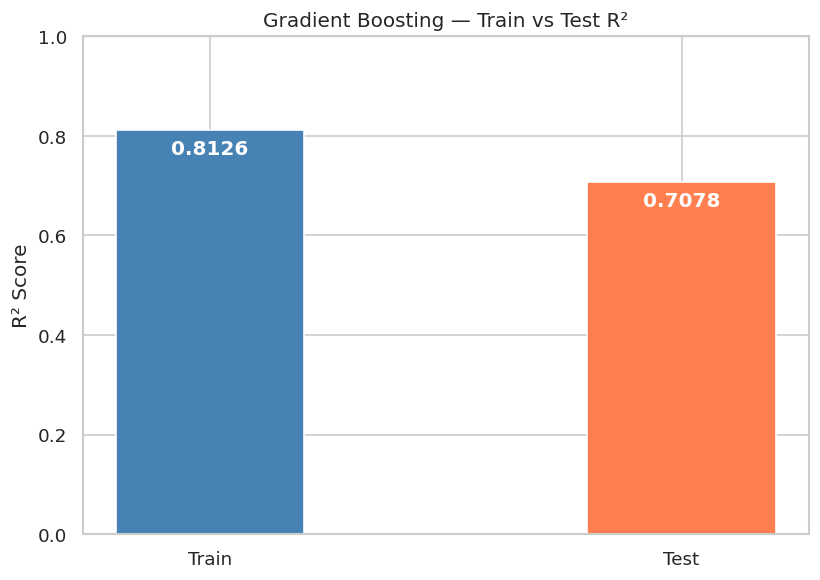

In [ ]:
# ============================================================
# FINAL MODEL: GRADIENT BOOSTING - R² TRAIN vs TEST
# ============================================================

best_gb = rs_gb.best_estimator_

y_pred_train_gb = best_gb.predict(X_train)
y_pred_test_gb  = best_gb.predict(X_test)

r2_train_gb = r2_score(y_train, y_pred_train_gb)
r2_test_gb  = r2_score(y_test,  y_pred_test_gb)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Train', 'Test'],
    [r2_train_gb, r2_test_gb],
    color=['steelblue', 'coral'],
    edgecolor='white',
    width=0.4
)

for bar, val in zip(bars, [r2_train_gb, r2_test_gb]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val - 0.02,
        f'{val:.4f}',
        ha='center', va='top',
        fontsize=12, fontweight='bold', color='white'
    )

ax.set_ylim(0, 1)
ax.set_ylabel('R² Score')
ax.set_title('Gradient Boosting — Train vs Test R²')
ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('gb_r2_train_test.png', dpi=150, bbox_inches='tight')
plt.show()

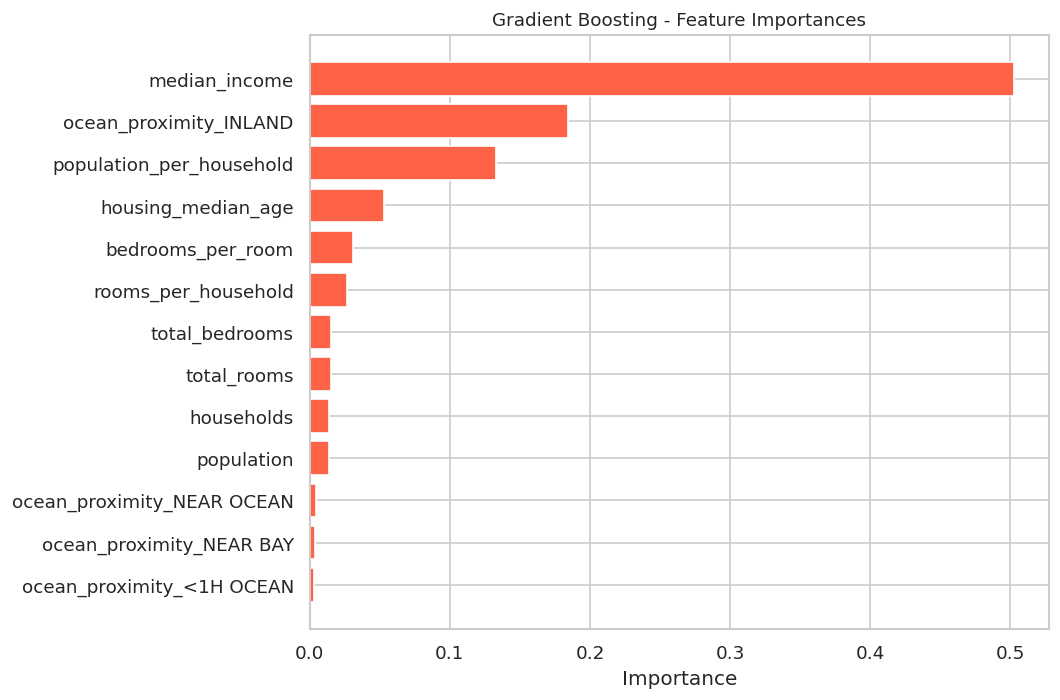

In [ ]:
# ============================================================
# FINAL MODEL: GRADIENT BOOSTING - VARIABLE IMPORTANCE
# ============================================================

feat_df = pd.DataFrame({
    'feature':    get_feature_names(best_gb),
    'importance': best_gb.named_steps['model'].feature_importances_
})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(feat_df['feature'], feat_df['importance'], color='tomato')
ax.set_title('Gradient Boosting - Feature Importances', fontsize=11)
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('variable_importance_gb_final.png', dpi=150, bbox_inches='tight')
plt.show()

#Unsupervised Learning (clustering)




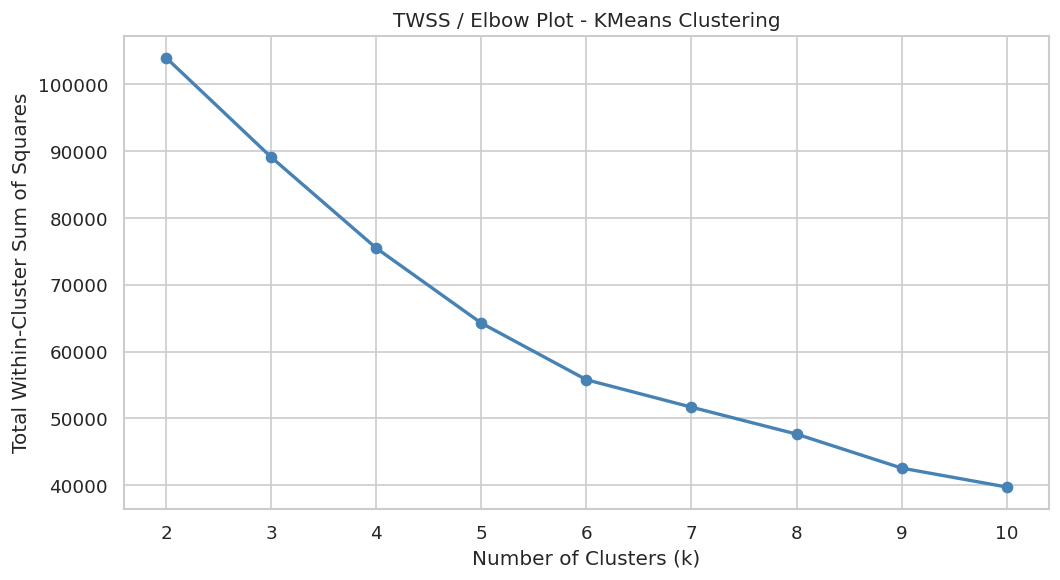

In [ ]:
# ============================================================
# CLUSTERING: TWSS / ELBOW PLOT With Lat+logitude
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# geographic + economic features for clustering
cluster_features = ['latitude', 'longitude', 'median_income',
                    'median_house_value', 'housing_median_age',
                    'rooms_per_household', 'population_per_household']

X_cluster = df[cluster_features].dropna()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

twss = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    twss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, twss, marker='o', color='steelblue', linewidth=2, markersize=6)
ax.set_title('TWSS / Elbow Plot - KMeans Clustering')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Total Within-Cluster Sum of Squares')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('twss_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

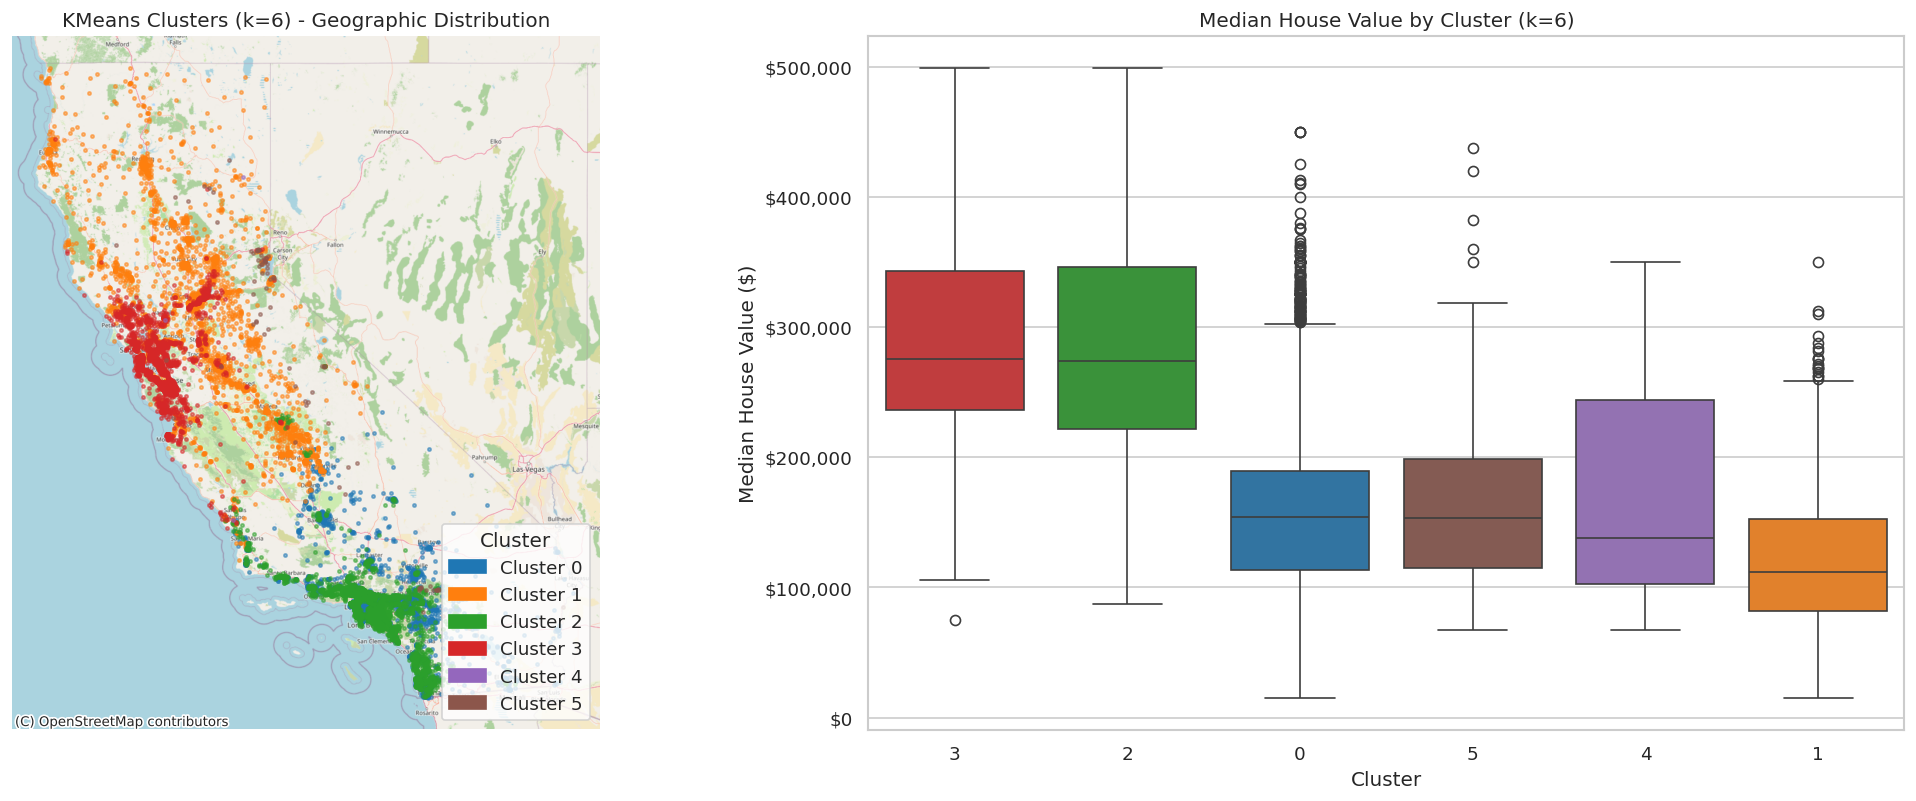

         latitude  longitude  median_income  median_house_value  housing_median_age  rooms_per_household  population_per_household
cluster                                                                                                                           
0         33.9200  -117.9300         2.8900         156121.6100             30.3400               4.6000                    3.2100
1         38.0800  -121.4200         2.7800         119577.1300             27.4400               5.2100                    2.8600
2         33.8900  -118.0600         5.3800         285230.8000             24.5200               6.1300                    2.8200
3         37.6700  -122.0900         5.0300         291134.2400             30.3800               5.8300                    2.8200
4         38.0200  -121.0600         6.6700         185000.0000             42.3300               5.8000                  781.8400
5         37.5100  -119.3400         3.7100         168512.3500             17.5400

In [ ]:
# ============================================================
# CLUSTERING-1: KMEANS
# ============================================================

import matplotlib.patches as mpatches

K_OPTIMAL = 6   # adjust based on elbow plot

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_cluster_scaled)

# Shared palette so map and boxplot use identical colors
palette    = sns.color_palette('tab10', K_OPTIMAL)
color_dict = {i: palette[i] for i in range(K_OPTIMAL)}
color_dict_str = {str(i): palette[i] for i in range(K_OPTIMAL)}

# --- Geographic plot coloured by cluster ---
geometry_cl = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf_cl = gpd.GeoDataFrame(df, geometry=geometry_cl, crs='EPSG:4326').to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Map: plot each cluster separately so colors match exactly
for cluster_id, group in gdf_cl.groupby('cluster'):
    group.plot(
        ax=axes[0],
        color=color_dict[cluster_id],
        alpha=0.5,
        markersize=4,
        label=f'Cluster {cluster_id}'
    )

ctx.add_basemap(axes[0], source=ctx.providers.OpenStreetMap.Mapnik, zoom=7)
axes[0].set_title(f'KMeans Clusters (k={K_OPTIMAL}) - Geographic Distribution')
axes[0].set_axis_off()

# Discrete legend on the map
legend_handles = [
    mpatches.Patch(color=color_dict[i], label=f'Cluster {i}')
    for i in range(K_OPTIMAL)
]
axes[0].legend(handles=legend_handles, title='Cluster',
               loc='lower right', framealpha=0.8)

# Boxplot: median house value by cluster, same palette
order_cl = (df.groupby('cluster')['median_house_value']
              .median()
              .sort_values(ascending=False)
              .index)
sns.boxplot(data=df, x='cluster', y='median_house_value',
            order=order_cl, palette=color_dict_str, ax=axes[1])
axes[1].set_title(f'Median House Value by Cluster (k={K_OPTIMAL})')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Median House Value ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cluster profile summary ---
cluster_profile = (df.groupby('cluster')[cluster_features]
                     .mean()
                     .round(2))
print(cluster_profile.to_string())

In [ ]:
# ============================================================
# CLUSTERING: TWSS / ELBOW PLOT Without Lat+logitude
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# economic features for clustering
cluster_features = [ 'median_income',
                    'median_house_value', 'housing_median_age',
                    'rooms_per_household', 'population_per_household']

X_cluster = df[cluster_features].dropna()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

twss = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    twss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, twss, marker='o', color='steelblue', linewidth=2, markersize=6)
ax.set_title('TWSS / Elbow Plot - KMeans Clustering')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Total Within-Cluster Sum of Squares')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('twss_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CLUSTERING-2: KMEANS
# ============================================================

import matplotlib.patches as mpatches

K_OPTIMAL = 4   # adjust based on elbow plot

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_cluster_scaled)

# Shared palette so map and boxplot use identical colors
palette    = sns.color_palette('tab10', K_OPTIMAL)
color_dict = {i: palette[i] for i in range(K_OPTIMAL)}
color_dict_str = {str(i): palette[i] for i in range(K_OPTIMAL)}

# --- Geographic plot coloured by cluster ---
geometry_cl = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf_cl = gpd.GeoDataFrame(df, geometry=geometry_cl, crs='EPSG:4326').to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Map: plot each cluster separately so colors match exactly
for cluster_id, group in gdf_cl.groupby('cluster'):
    group.plot(
        ax=axes[0],
        color=color_dict[cluster_id],
        alpha=0.5,
        markersize=4,
        label=f'Cluster {cluster_id}'
    )

ctx.add_basemap(axes[0], source=ctx.providers.OpenStreetMap.Mapnik, zoom=7)
axes[0].set_title(f'KMeans Clusters (k={K_OPTIMAL}) - Geographic Distribution')
axes[0].set_axis_off()

# Discrete legend on the map
legend_handles = [
    mpatches.Patch(color=color_dict[i], label=f'Cluster {i}')
    for i in range(K_OPTIMAL)
]
axes[0].legend(handles=legend_handles, title='Cluster',
               loc='lower right', framealpha=0.8)

# Boxplot: median house value by cluster, same palette
order_cl = (df.groupby('cluster')['median_house_value']
              .median()
              .sort_values(ascending=False)
              .index)
sns.boxplot(data=df, x='cluster', y='median_house_value',
            order=order_cl, palette=color_dict_str, ax=axes[1])
axes[1].set_title(f'Median House Value by Cluster (k={K_OPTIMAL})')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Median House Value ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cluster profile summary ---
cluster_profile = (df.groupby('cluster')[cluster_features]
                     .mean()
                     .round(2))
print(cluster_profile.to_string())

In [ ]:
# ============================================================
# CLUSTERING: CLUSTER PROPORTIONS - PIE CHART
# ============================================================

cluster_counts = df['cluster'].value_counts().sort_index()
cluster_labels = [f'Cluster {i}' for i in cluster_counts.index]

print("=== CLUSTER INSTANCE COUNTS ===\n")
for i, (label, count) in enumerate(zip(cluster_labels, cluster_counts)):
    print(f"  {label}: {count:,} instances ({count / len(df) * 100:.1f}%)")
print(f"\n  Total: {len(df):,} instances")

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    cluster_counts,
    labels=cluster_labels,
    colors=sns.color_palette('tab10', len(cluster_counts)),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Cluster Proportions', fontsize=13)

plt.tight_layout()
plt.savefig('cluster_proportions.png', dpi=150, bbox_inches='tight')
plt.show()